# f1 gp
this notebook serves to create the visualizations to populate the articles available in https://f1observatory.blogspot.com/

# import necessary packages

In [1]:
import fastf1
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
from fastf1 import plotting
from fastf1.ergast import Ergast
ERGAST = Ergast()
from pandasql import sqldf
import requests
from fastf1.core import SessionResults

# define variables, dictionaries & dataframes

In [2]:
GP = "China"
GP_NAME = "Chinese Grand Prix"
SEASON = 2026
ROUND_NUMBER = 2

In [67]:
GRAND_PRIXS = {
    "ROUND": list(range(1, 25)),
    "GRAND_PRIX_NAME": ["Australia", "China", "Japan", "Bahrain", "Saudi Arabia ", "Miami", "Canada", "Monaco", "Barcelona", "Austria", "Great Britain", "Belgium", "Hungary", "Netherlands", "Italy", "Spain", "Azerbaijan", "Singapore", "United States", "Mexico", "Brazil", "Las Vegas", "Qatar", "Abu Dhabi"]
    }
GRAND_PRIXS = pd.DataFrame(GRAND_PRIXS)

DRIVERS = ['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'PIA', 'VER', 'HAD', 'OCO', 'BEA', 'LAW', 'LIN', 'HUL', 'BOR', 'GAS', 'COL', 'SAI', 'ALB', 'PER', 'BOT', 'ALO', 'STR']

TEAMS = ['Mercedes', 'Ferrari', 'McLaren', 'Red Bull', 'Haas F1 Team', 'RB F1 Team', 'Audi', 'Alpine F1 Team', 'Williams', 'Cadillac F1 Team', 'Aston Martin']

PALETTE_DRIVERS = {
    'RUS': '#27f4d2',
    'ANT': '#27f4d2',
    'LEC': '#e8002d',
    'HAM': '#e8002d',
    'NOR': '#ff8000',
    'PIA': '#ff8000',
    'VER': '#0600ef',
    'HAD': '#0600ef',
    'OCO': '#b6babd',
    'BEA': '#b6babd',
    'LAW': '#364aa9',
    'LIN': '#364aa9',
    'HUL': '#FF2D00',
    'BOR': '#FF2D00',
    'GAS': '#ff87bc',
    'COL': '#ff87bc',
    'SAI': '#00a0dd',
    'ALB': '#00a0dd',
    'PER': '#AAAADD',
    'BOT': '#AAAADD',
    'ALO': '#00665f',
    'STR': '#00665f'
    }

DRIVER_STYLES = {
    'RUS': 'solid',
    'ANT': 'dashed',
    'LEC': 'solid',
    'HAM': 'dashed',
    'NOR': 'solid',
    'PIA': 'dashed',
    'VER': 'solid',
    'HAD': 'dashed',
    'OCO': 'solid',
    'BEA': 'dashed',
    'LAW': 'solid',
    'LIN': 'dashed',
    'HUL': 'solid',
    'BOR': 'dashed',
    'GAS': 'solid',
    'COL': 'dashed',
    'SAI': 'solid',
    'ALB': 'dashed',
    'PER': 'solid',
    'BOT': 'dashed',
    'ALO': 'solid',
    'STR': 'dashed'
    }

PALETTE_TEAMS = {
    'McLaren': '#ff8000',
    'Red Bull': '#0600ef',
    'Mercedes': '#27f4d2',
    'Williams': '#00a0dd',
    'Aston Martin': '#00665f',
    'Audi': '#FF2D00',
    'Ferrari': '#e8002d',
    'Alpine F1 Team': '#ff87bc',
    'RB F1 Team': '#364aa9',
    'Haas F1 Team': '#b6babd',
    'Cadillac F1 Team': '#AAAADD'
    }

COMPOUND_COLORS = {
    'SOFT': '#da291c',
    'MEDIUM': '#ffd12e',
    'HARD': '#f0f0ec',
    'INTERMEDIATE': '#43b02a',
    'WET': '#0067ad',
    'UNKNOWN': '#00ffff',
    'TEST-UNKNOWN': '#434649'
    }

# the track

req         WARNING 	DEFAULT CACHE ENABLED! (593.84 MB) C:\Users\nb30499\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching t

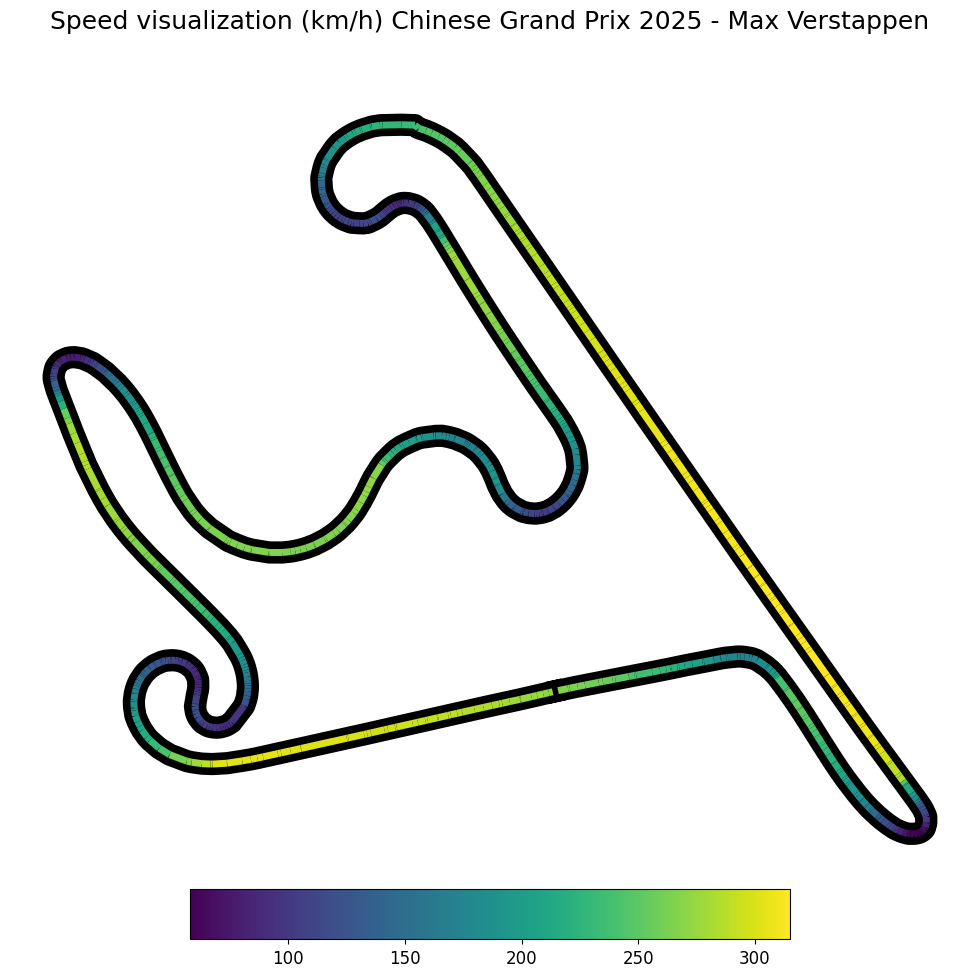

In [4]:
RACE_LY = fastf1.get_session(SEASON - 1, GP, 'R')
RACE_LY.load()
LAP = RACE_LY.laps.pick_driver("VER").pick_fastest()

X = LAP.telemetry["X"]
Y = LAP.telemetry["Y"]
COLOR = LAP.telemetry["Speed"]
COLORMAP = mpl.cm.viridis

POINTS = np.array([X, Y]).T.reshape(-1, 1, 2)
SEGMENTS = np.concatenate([POINTS[:-1], POINTS[1:]], axis=1)

plt.style.use('default')
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(sharex=True, sharey=True, figsize=(12, 10))
fig.suptitle(f"Speed visualization (km/h) {GP_NAME} {SEASON - 1} - Max Verstappen", size=18)

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.12)
ax.axis('off')

ax.plot(LAP.telemetry['X'], LAP.telemetry['Y'], color='black', linestyle='-', linewidth=16, zorder=0)

norm = plt.Normalize(COLOR.min(), COLOR.max())
lc = LineCollection(SEGMENTS, cmap=COLORMAP, norm=norm, linestyle='-', linewidth=5)

lc.set_array(COLOR)

line = ax.add_collection(lc)

cbaxes = fig.add_axes([0.25, 0.05, 0.5, 0.05])
normlegend = mpl.colors.Normalize(vmin=COLOR.min(), vmax=COLOR.max())
legend = mpl.colorbar.ColorbarBase(cbaxes, norm=normlegend, cmap=COLORMAP, orientation="horizontal")

plt.show()

# load GP events

In [5]:
FP1 = fastf1.get_session(SEASON, GP, 'FP1')
FP1.load()
SQ = fastf1.get_session(SEASON, GP, 'SQ')
SQ.load()
S = fastf1.get_session(SEASON, GP, 'S')
S.load()
Q = fastf1.get_session(SEASON, GP, 'Q')
Q.load(telemetry=True)
RACE = fastf1.get_session(SEASON, GP, 'R')
RACE.load()

core           INFO 	Loading data for Chinese Grand Prix - Practice 1 [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

# free practices

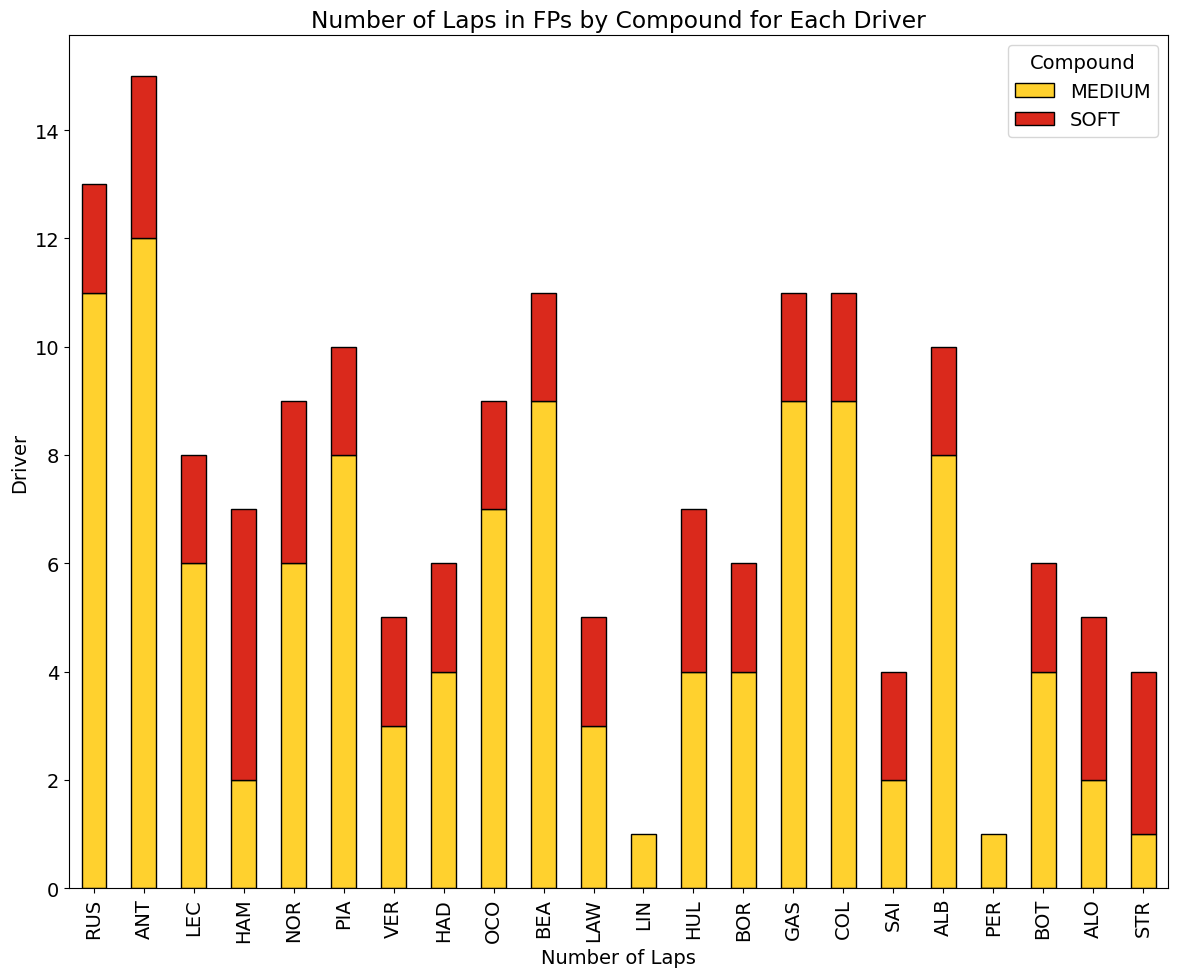

In [6]:
FP_LAPS = FP1.laps.pick_quicklaps()

LAPS_BY_DRIVER = sqldf("SELECT Driver, Compound, COUNT(DISTINCT LapNumber) AS nrLaps FROM FP_LAPS GROUP BY Driver, Compound")

DF_PIVOT = LAPS_BY_DRIVER.pivot_table(index='Driver', columns='Compound', values='nrLaps', aggfunc='sum', fill_value=0)
DRIVER_ORDER = ['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'PIA', 'VER', 'HAD', 'OCO', 'BEA', 'LAW', 'LIN', 'HUL', 'BOR', 'GAS', 'COL', 'SAI', 'ALB', 'PER', 'BOT', 'ALO', 'STR']
DF_PIVOT = DF_PIVOT.reindex(DRIVER_ORDER)
COLORS = [COMPOUND_COLORS.get(compound, '#333333') for compound in DF_PIVOT.columns]

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))
DF_PIVOT.plot(kind='bar', stacked=True, color=COLORS, edgecolor='black', ax=ax)

from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Number of Laps")
ax.set_ylabel("Driver")
ax.set_title("Number of Laps in FPs by Compound for Each Driver")
ax.legend(title="Compound")
ax.set_xticks(range(len(DRIVER_ORDER)))
ax.set_xticklabels(DRIVER_ORDER, rotation=90)

plt.tight_layout()
plt.show()

In [8]:
FP_LAPS.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

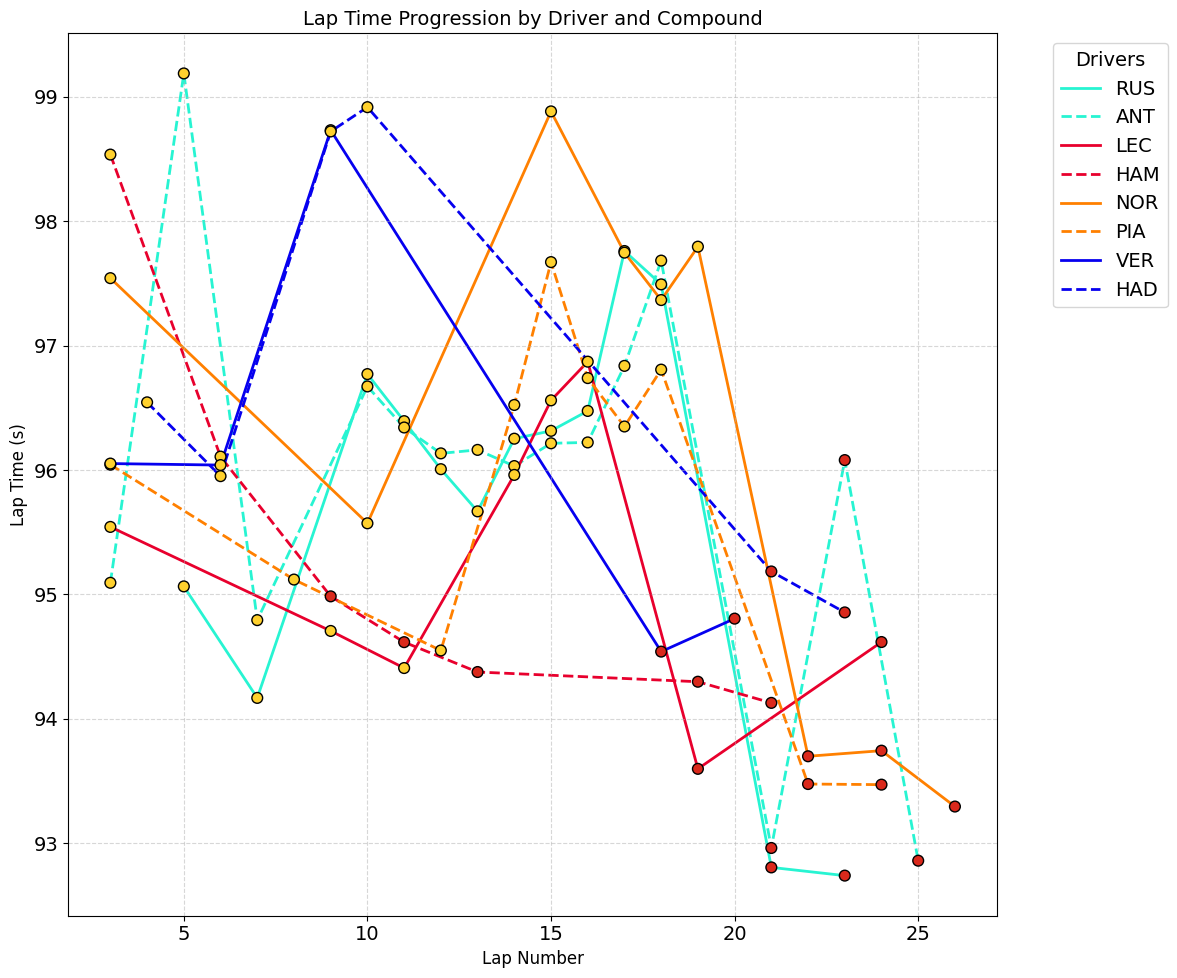

In [12]:
TIME_LAPS = sqldf("SELECT * FROM FP_LAPS WHERE Driver IN ('RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'PIA', 'VER', 'HAD')")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

TIME_LAPS['LapTime'] = pd.to_timedelta(TIME_LAPS['LapTime'], errors='coerce')
TIME_LAPS["LapTime(s)"] = TIME_LAPS["LapTime"].dt.total_seconds()

TOP_8_DRIVERS = ['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'PIA', 'VER', 'HAD']

for driver in TOP_8_DRIVERS:
    driver_df = TIME_LAPS[TIME_LAPS['Driver'] == driver].sort_values('LapNumber')
    
    line_color = PALETTE_DRIVERS.get(driver, 'black')
    line_style = DRIVER_STYLES.get(driver, '-')
    
    plt.plot(driver_df['LapNumber'], driver_df['LapTime(s)'], 
             color = line_color, 
             linestyle = line_style, 
             label = driver, 
             linewidth = 2, 
             zorder = 1)
    
    marker_colors = [COMPOUND_COLORS.get(c, 'grey') for c in driver_df['Compound']]
    
    plt.scatter(driver_df['LapNumber'], driver_df['LapTime(s)'], 
                c = marker_colors, 
                edgecolors = 'black', 
                linewidths = 1, 
                s = 60, 
                zorder = 2)

plt.title('Lap Time Progression by Driver and Compound', fontsize = 14)
plt.xlabel('Lap Number', fontsize = 12)
plt.ylabel('Lap Time (s)', fontsize = 12)
plt.legend(title = 'Drivers', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.tight_layout()
plt.show()

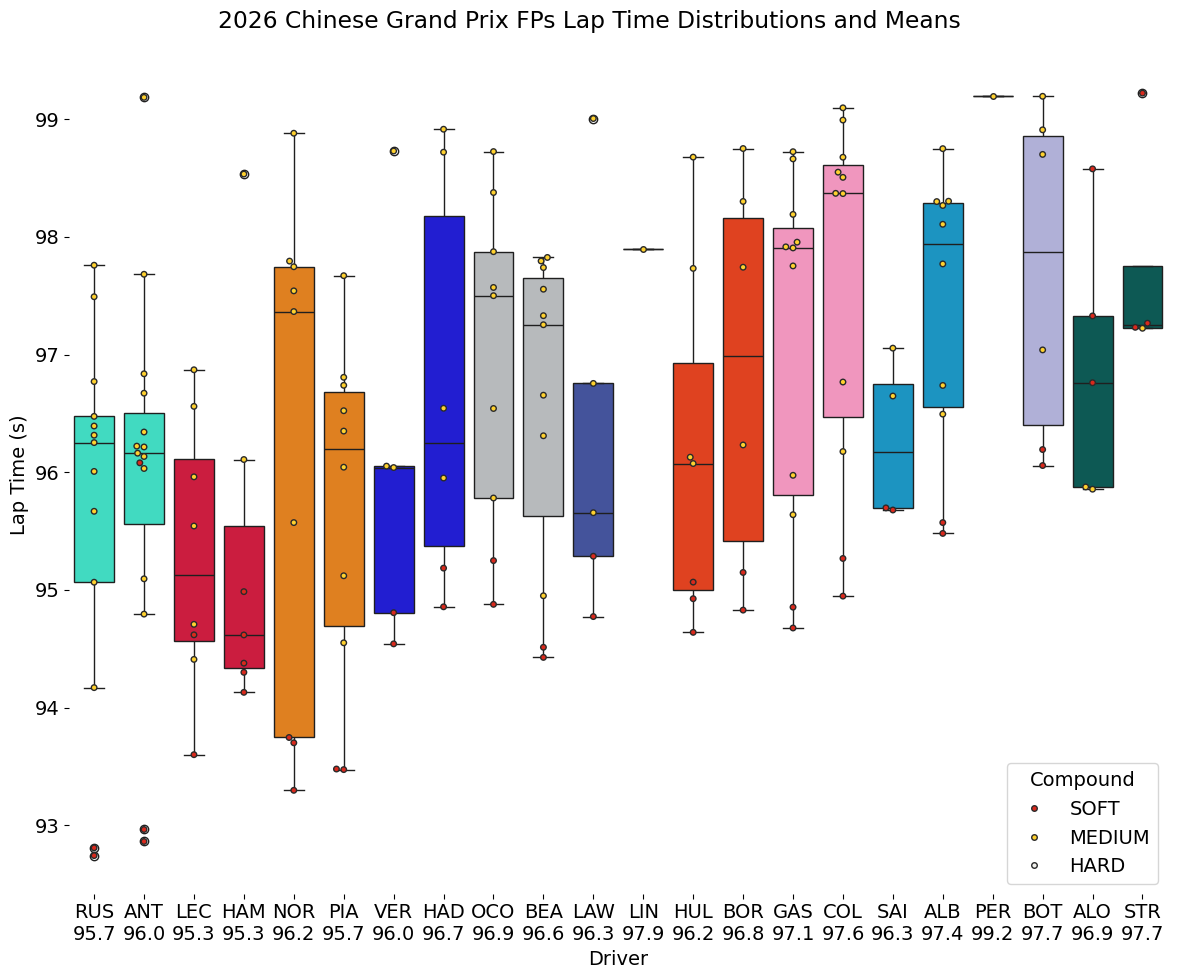

In [13]:
TIME_LAPS = FP_LAPS

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

TIME_LAPS['LapTime'] = pd.to_timedelta(TIME_LAPS['LapTime'], errors='coerce')
TIME_LAPS["LapTime(s)"] = TIME_LAPS["LapTime"].dt.total_seconds()

sns.boxplot(data=TIME_LAPS,
            x="Driver",
            y="LapTime(s)",
            hue="Driver",
            order=['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'PIA', 'VER', 'HAD', 'OCO', 'BEA', 'LAW', 'LIN', 'HUL', 'BOR', 'GAS', 'COL', 'SAI', 'ALB', 'PER', 'BOT', 'ALO', 'STR'],
            palette=PALETTE_DRIVERS
            )

sns.swarmplot(data=TIME_LAPS,
              x="Driver",
              y="LapTime(s)",
              hue="Compound",
              palette=COMPOUND_COLORS,
              hue_order=["SOFT", "MEDIUM", "HARD"],
              linewidth=1,
              size=4,
              )

MEANS = TIME_LAPS.groupby('Driver')["LapTime(s)"].mean().reindex(['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'PIA', 'VER', 'HAD', 'OCO', 'BEA', 'LAW', 'LIN', 'HUL', 'BOR', 'GAS', 'COL', 'SAI', 'ALB', 'PER', 'BOT', 'ALO', 'STR'])
ax.set_xticks(range(len(MEANS)))
ax.set_xticklabels([f"{driver}\n{mean:.1f}" for driver, mean in MEANS.items()])
ax.set_xlabel("Driver")
ax.set_ylabel("Lap Time (s)")
plt.suptitle(f"{SEASON} " + str(RACE.event['EventName']) + f" FPs Lap Time Distributions and Means")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# sprint qualifying

In [14]:
SQ.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
63,63,G RUSSELL,RUS,,Mercedes,00D7B6,,George,Russell,George Russell,...,1.0,,NaN,0 days 00:01:33.030000,0 days 00:01:32.241000,0 days 00:01:31.520000,NaT,,NaN,NaN
12,12,K ANTONELLI,ANT,,Mercedes,00D7B6,,Kimi,Antonelli,Kimi Antonelli,...,2.0,,NaN,0 days 00:01:33.455000,0 days 00:01:32.291000,0 days 00:01:31.809000,NaT,,NaN,NaN
1,1,L NORRIS,NOR,,McLaren,F47600,,Lando,Norris,Lando Norris,...,3.0,,NaN,0 days 00:01:33.783000,0 days 00:01:33.086000,0 days 00:01:32.141000,NaT,,NaN,NaN
44,44,L HAMILTON,HAM,,Ferrari,ED1131,,Lewis,Hamilton,Lewis Hamilton,...,4.0,,NaN,0 days 00:01:33.148000,0 days 00:01:33.042000,0 days 00:01:32.161000,NaT,,NaN,NaN
81,81,O PIASTRI,PIA,,McLaren,F47600,,Oscar,Piastri,Oscar Piastri,...,5.0,,NaN,0 days 00:01:33.813000,0 days 00:01:33.038000,0 days 00:01:32.224000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,,Ferrari,ED1131,,Charles,Leclerc,Charles Leclerc,...,6.0,,NaN,0 days 00:01:33.194000,0 days 00:01:32.602000,0 days 00:01:32.528000,NaT,,NaN,NaN
10,10,P GASLY,GAS,,Alpine,00A1E8,,Pierre,Gasly,Pierre Gasly,...,7.0,,NaN,0 days 00:01:33.970000,0 days 00:01:33.405000,0 days 00:01:32.888000,NaT,,NaN,NaN
3,3,M VERSTAPPEN,VER,,Red Bull Racing,4781D7,,Max,Verstappen,Max Verstappen,...,8.0,,NaN,0 days 00:01:34.170000,0 days 00:01:33.564000,0 days 00:01:33.254000,NaT,,NaN,NaN
87,87,O BEARMAN,BEA,,Haas F1 Team,9C9FA2,,Oliver,Bearman,Oliver Bearman,...,9.0,,NaN,0 days 00:01:34.280000,0 days 00:01:33.501000,0 days 00:01:33.409000,NaT,,NaN,NaN
6,6,I HADJAR,HAD,,Red Bull Racing,4781D7,,Isack,Hadjar,Isack Hadjar,...,10.0,,NaN,0 days 00:01:34.447000,0 days 00:01:33.620000,0 days 00:01:33.723000,NaT,,NaN,NaN


In [15]:
SQ_RESULTS = SQ.results
SQ_RESULTS = SQ_RESULTS[["Abbreviation", "Position", "Q1", "Q2", "Q3"]]
SQ_RESULTS = sqldf(
    """
    SELECT "Abbreviation", "Position", CASE WHEN Position BETWEEN 1 AND 10 THEN Q3 WHEN Position BETWEEN 11 AND 15 THEN Q2 ELSE Q1 END AS Time
    FROM SQ_RESULTS
    """
)
SQ_RESULTS['Time'] = pd.to_timedelta(SQ_RESULTS['Time'])
SQ_RESULTS["LapTime"] = SQ_RESULTS["Time"].dt.total_seconds()
SQ_RESULTS

,Abbreviation,Position,Time,LapTime
0,RUS,1.0,0 days 00:01:31.520000,91.520
1,ANT,2.0,0 days 00:01:31.809000,91.809
2,NOR,3.0,0 days 00:01:32.141000,92.141
3,HAM,4.0,0 days 00:01:32.161000,92.161
4,PIA,5.0,0 days 00:01:32.224000,92.224
5,LEC,6.0,0 days 00:01:32.528000,92.528
6,GAS,7.0,0 days 00:01:32.888000,92.888
7,VER,8.0,0 days 00:01:33.254000,93.254
8,BEA,9.0,0 days 00:01:33.409000,93.409
9,HAD,10.0,0 days 00:01:33.723000,93.723


posx and posy should be finite values
posx and posy should be finite values


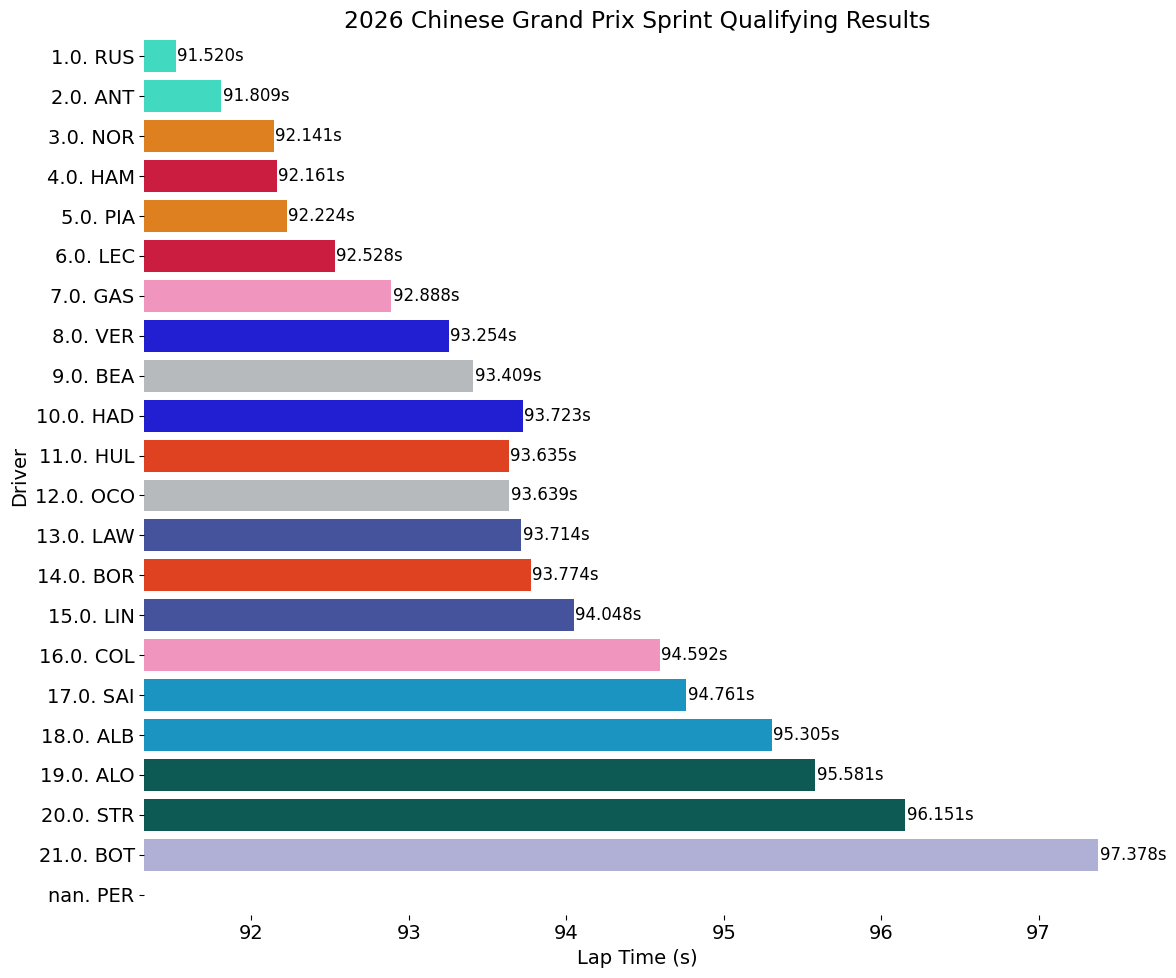

In [17]:
SQ_RESULTS['Position_Abbreviation'] = SQ_RESULTS['Position'].astype(str) + '. ' + SQ_RESULTS['Abbreviation']

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

sns.barplot(data=SQ_RESULTS,
            y='Position_Abbreviation', 
            x='LapTime',
            hue='Abbreviation', 
            dodge=False,
            palette=PALETTE_DRIVERS, 
            ax=ax
            )

for index, row in SQ_RESULTS.iterrows():
    ax.text(row['LapTime'] + 0.01, index, f'{row["LapTime"]:.3f}s', va='center', fontsize=12)

ax.set_xlim(SQ_RESULTS['LapTime'].min() - 0.2, SQ_RESULTS['LapTime'].max() + 0.2)
ax.set_xlabel("Lap Time (s)")
ax.set_ylabel("Driver")
ax.set_title(f"{SEASON} {RACE.event['EventName']} Sprint Qualifying Results")

sns.despine(left=True, bottom=True)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

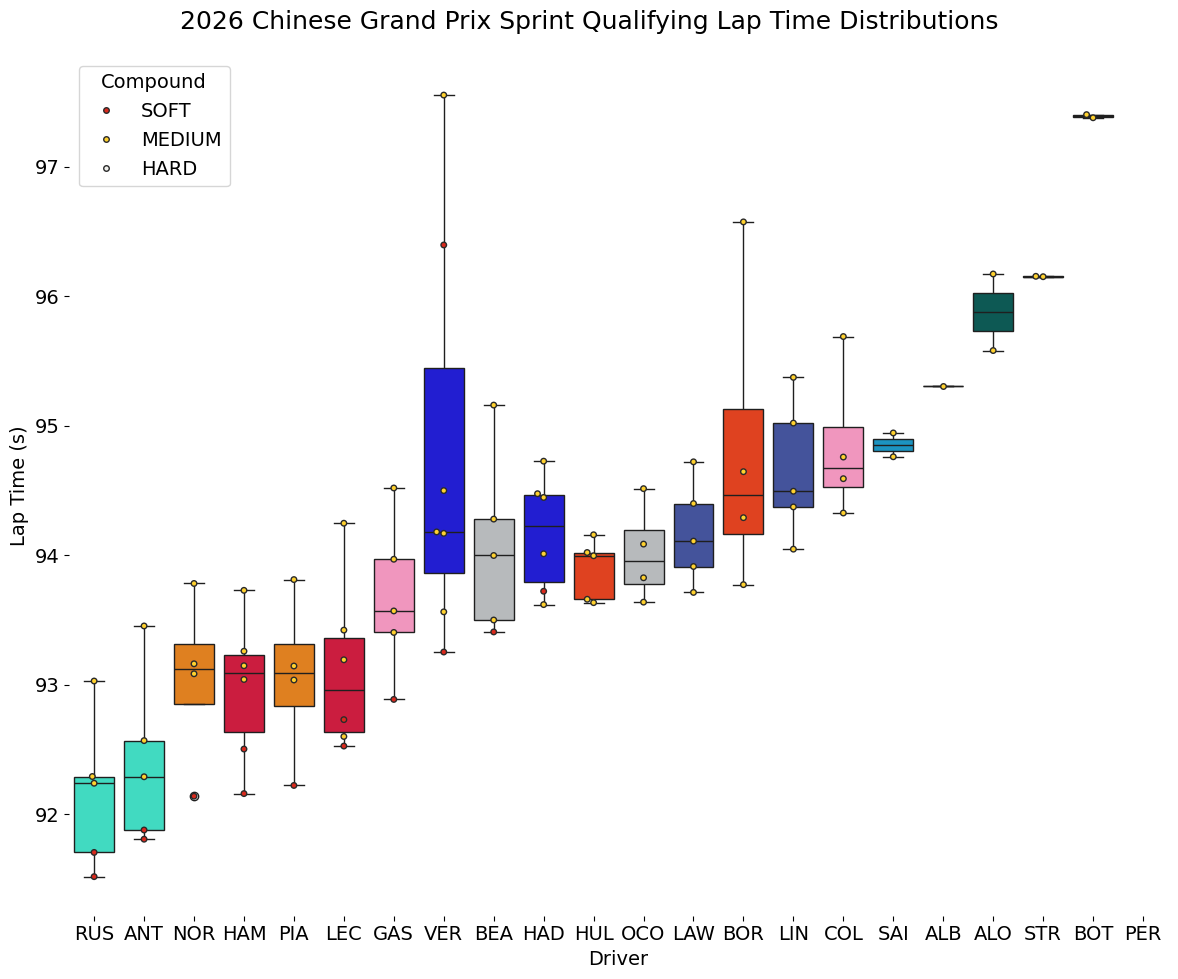

In [18]:
SQ_LAPS = SQ.laps.pick_quicklaps()
SQ_LAPS["LapTime"] = pd.to_timedelta(SQ_LAPS["LapTime"], errors="coerce")
SQ_LAPS["LapTime"] = SQ_LAPS["LapTime"].dt.total_seconds()

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

sns.boxplot(data=SQ_LAPS,
            x="Driver",
            y="LapTime",
            hue="Driver",
            order=SQ_RESULTS["Abbreviation"],
            palette=PALETTE_DRIVERS
            )

sns.swarmplot(data=SQ_LAPS,
              x="Driver",   
              y="LapTime",
              hue="Compound",
              palette=COMPOUND_COLORS,
              hue_order=["SOFT", "MEDIUM", "HARD"],
              linewidth=1,
              size=4,
              )

ax.set_xlabel("Driver")
ax.set_ylabel("Lap Time (s)")
plt.suptitle(f"{SEASON} " + str(RACE.event['EventName']) + " Sprint Qualifying Lap Time Distributions", fontsize=18)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [21]:
SQ_RESULTS

,Abbreviation,Position,Time,LapTime,Position_Abbreviation
0,RUS,1.0,0 days 00:01:31.520000,91.520,1.0. RUS
1,ANT,2.0,0 days 00:01:31.809000,91.809,2.0. ANT
2,NOR,3.0,0 days 00:01:32.141000,92.141,3.0. NOR
3,HAM,4.0,0 days 00:01:32.161000,92.161,4.0. HAM
4,PIA,5.0,0 days 00:01:32.224000,92.224,5.0. PIA
5,LEC,6.0,0 days 00:01:32.528000,92.528,6.0. LEC
6,GAS,7.0,0 days 00:01:32.888000,92.888,7.0. GAS
7,VER,8.0,0 days 00:01:33.254000,93.254,8.0. VER
8,BEA,9.0,0 days 00:01:33.409000,93.409,9.0. BEA
9,HAD,10.0,0 days 00:01:33.723000,93.723,10.0. HAD


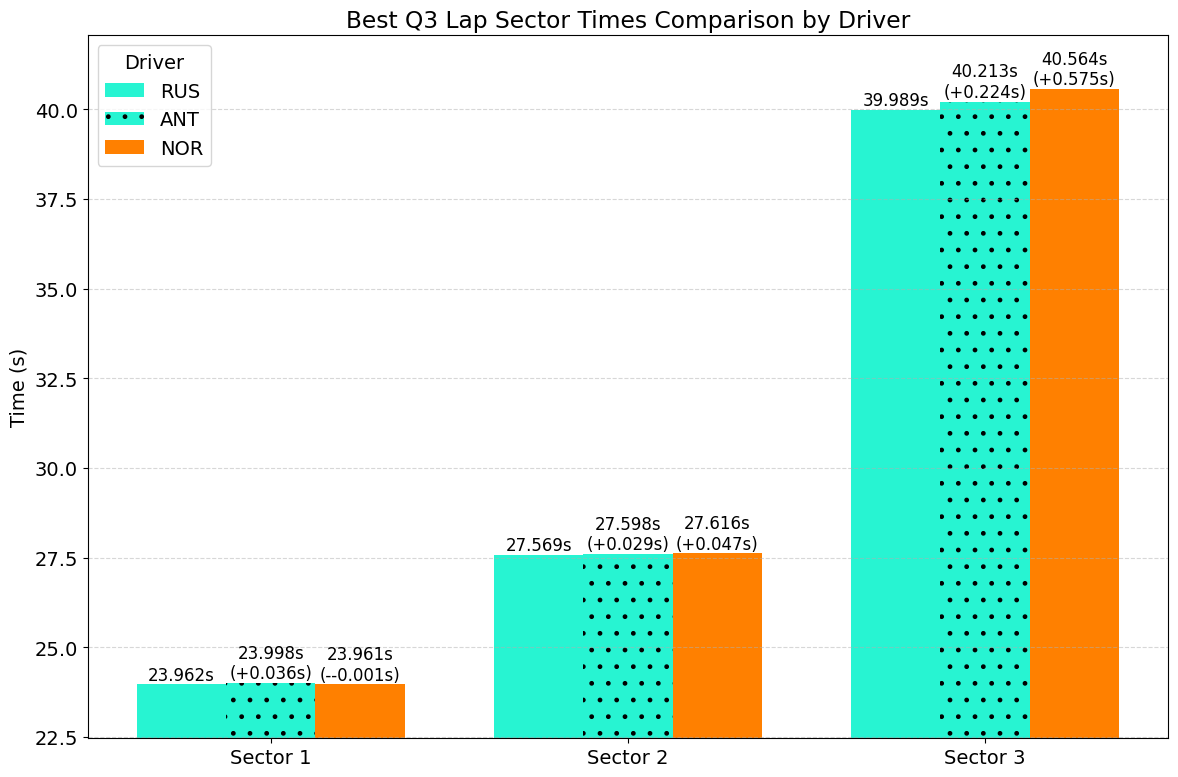

In [23]:
SECTOR_COMP = sqldf(
    """
    SELECT SQ_RESULTS.Position, SQ_LAPS.Driver, SQ_LAPS.Sector1Time, SQ_LAPS.Sector2Time, SQ_LAPS.Sector3Time
    FROM SQ_RESULTS
    JOIN SQ_LAPS ON SQ_RESULTS.Abbreviation = SQ_LAPS.DRIVER AND SQ_RESULTS.LapTime = SQ_LAPS.LapTime
    WHERE SQ_RESULTS.Position BETWEEN 1 AND 3
    ORDER BY SQ_RESULTS.Position
    """
)

SECTOR_COMP["Sector1Time"] = pd.to_timedelta(SECTOR_COMP["Sector1Time"], errors="coerce")
SECTOR_COMP["Sector2Time"] = pd.to_timedelta(SECTOR_COMP["Sector2Time"], errors="coerce")
SECTOR_COMP["Sector3Time"] = pd.to_timedelta(SECTOR_COMP["Sector3Time"], errors="coerce")

SECTOR_LONG = SECTOR_COMP.melt(id_vars=['Driver','Position'],
                                value_vars=['Sector1Time', 'Sector2Time', 'Sector3Time'],
                                var_name='Sector',
                                value_name='Time'
                                )

SECTOR_LONG['Sector'] = SECTOR_LONG['Sector'].str.replace('Sector', 'Sector ', regex=False)
SECTOR_LONG['TimeSeconds'] = SECTOR_LONG['Time'].dt.total_seconds()

SECTOR_LONG_1 = sqldf("SELECT * FROM SECTOR_LONG WHERE Position = 1")
SECTOR_LONG = sqldf(
    """
    SELECT A.*, CASE WHEN A.TimeSeconds - B.TimeSeconds > 0 THEN concat('+', round(A.TimeSeconds - B.TimeSeconds, 3)) ELSE concat('-', round(A.TimeSeconds - B.TimeSeconds, 3)) END AS Difference
    FROM SECTOR_LONG A
    JOIN SECTOR_LONG_1 B ON A.Sector = B.Sector
    """
)

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 8))

SECTORS = ['Sector 1', 'Sector 2', 'Sector 3']
x = np.arange(len(SECTORS))
bar_width = 0.25

# Plot each driver's sector times
for i, driver in enumerate(SECTOR_LONG['Driver'].unique()):
    driver_data = SECTOR_LONG[SECTOR_LONG['Driver'] == driver].sort_values('Sector')
    times = driver_data['TimeSeconds'].values
    diffs = driver_data['Difference'].values
    positions = driver_data['Position'].values
    bars = ax.bar(x + i * bar_width,
           times,
           width=bar_width,
           label=driver,
           color=PALETTE_DRIVERS[driver],
           hatch='.' if DRIVER_STYLES[driver] == 'dashed' else ''
           )
    for j, time in enumerate(times):
        if positions[j] == 1:
            label_text = f'{time:.3f}s'
        else:
            label_text = f'{time:.3f}s\n({diffs[j]}s)'
        
        ax.text(x[j] + i * bar_width,
                time + 0.02,
                label_text,
                ha='center',
                va='bottom',
                fontsize=12)

# Ticks and labels
ax.set_xticks(x + bar_width)
ax.set_xticklabels(SECTORS)
ax.set_ylabel("Time (s)")
y_min = SECTOR_LONG['TimeSeconds'].min() - 1.5
y_max = SECTOR_LONG['TimeSeconds'].max() + 1.5
ax.set_ylim(y_min, y_max)
ax.set_title("Best Q3 Lap Sector Times Comparison by Driver")
ax.legend(title="Driver")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

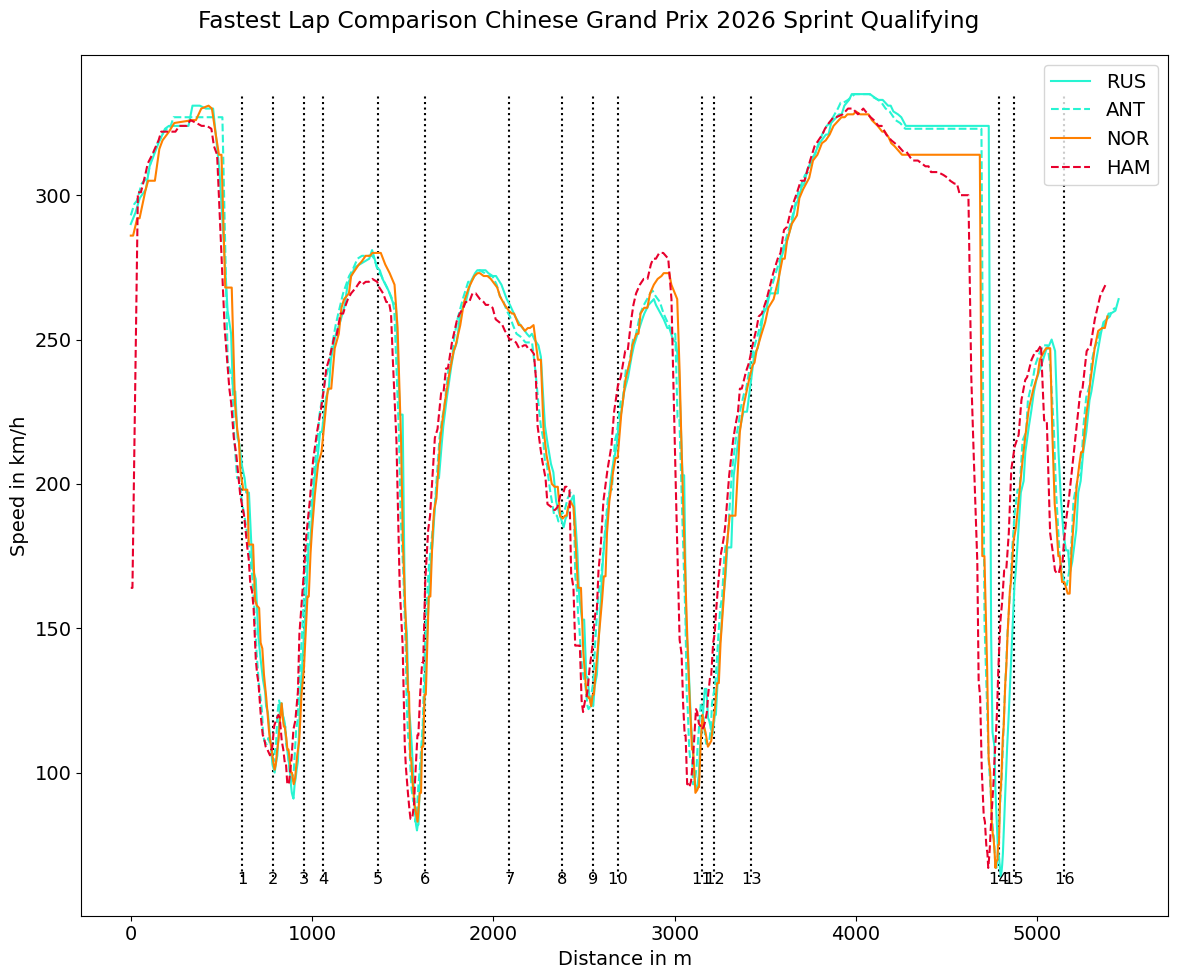

In [34]:
from urllib.request import urlopen
import json

COUNTRY = "China"

# GET SESSION NUMBER
BASE_URL = f"https://api.openf1.org/v1/sessions?year={SEASON}&country_name={COUNTRY}"
response = urlopen(BASE_URL)
data = json.loads(response.read().decode('utf-8'))
sessions = pd.DataFrame(data)
SESSION_KEY = int(sessions.loc[sessions['session_name'] == 'Sprint Qualifying', 'session_key'].iloc[0])

# GET BEST 4 DRIVERS IN QUALI
SQ_DRIVER_1 = int(SQ.results.loc[SQ.results['Position'] == 1, 'DriverNumber'].iloc[0])
SQ_DRIVER_2 = int(SQ.results.loc[SQ.results['Position'] == 2, 'DriverNumber'].iloc[0])
SQ_DRIVER_3 = int(SQ.results.loc[SQ.results['Position'] == 3, 'DriverNumber'].iloc[0])
SQ_DRIVER_4 = int(SQ.results.loc[SQ.results['Position'] == 4, 'DriverNumber'].iloc[0])

params = {
    'session_key': SESSION_KEY,
    'driver_number': [SQ_DRIVER_1, SQ_DRIVER_2, SQ_DRIVER_3, SQ_DRIVER_4]
}

# GET TELEMETRY DATA
response = requests.get("https://api.openf1.org/v1/car_data", params=params)
data = response.json()
car_data = pd.DataFrame(data)
car_data['date'] = pd.to_datetime(car_data['date'], format='ISO8601')

# GET BEST LAPS FROM EACH TO KNOW WHEN THEY STARTED
response = requests.get("https://api.openf1.org/v1/laps", params=params)
data = response.json()
laps = pd.DataFrame(data)
best_times_df = (laps.groupby('driver_number')['lap_duration']
                 .min()
                 .reset_index(name='best_time'))

best_laps = pd.merge(laps, best_times_df, left_on = ['driver_number', 'lap_duration'], right_on = ['driver_number', 'best_time'])
best_laps['date_start'] = pd.to_datetime(best_laps['date_start'])
best_laps['lap_duration'] = pd.to_timedelta(best_laps['lap_duration'], unit='s')
best_laps['date_end'] = best_laps['date_start'] + best_laps['lap_duration']
best_laps = best_laps[['driver_number', 'date_start', 'lap_duration', 'date_end']]

# CROSS INFO: TELEMETRY X BEST LAPS
telemetry = sqldf(
    """
    SELECT c.*
    FROM car_data c
    JOIN best_laps l ON c.driver_number = l.driver_number AND c.date BETWEEN l.date_start AND l.date_end
    """
)

# DRIVERS
response = requests.get("https://api.openf1.org/v1/drivers", params=params)
data = response.json()
drivers = pd.DataFrame(data)
drivers = drivers[['driver_number', 'name_acronym']].drop_duplicates()

# CROSS INFO: TELEMETRY X DRIVERS
telemetry = pd.merge(telemetry, drivers, left_on = ['driver_number'], right_on = ['driver_number'])

# CALCULATE DISTANCE
telemetry['date'] = pd.to_datetime(telemetry['date'])
telemetry = telemetry.sort_values(by=['driver_number', 'date'])
telemetry['dt'] = telemetry.groupby('driver_number')['date'].diff().dt.total_seconds().fillna(0)
telemetry['speed_ms'] = telemetry['speed'] / 3.6
telemetry['dist_inc'] = telemetry['speed_ms'] * telemetry['dt']
telemetry['distance'] = telemetry.groupby('driver_number')['dist_inc'].cumsum()

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

CIRCUIT_INFO = Q.get_circuit_info()

for _, corner in CIRCUIT_INFO.corners.iterrows():
    txt = f"{corner['Number']}{corner['Letter']}"
    ax.text(
        corner['Distance'], 
        telemetry['speed'].min() - 0.5,
        txt, va='center_baseline', ha='center', size='small'
    )

ax.vlines(
    x = CIRCUIT_INFO.corners['Distance'], 
    ymin = telemetry["speed"].min(), 
    ymax = telemetry["speed"].max(), 
    linestyles = 'dotted', 
    colors = 'black'
    )

driver_1_tel = telemetry[telemetry['driver_number'] == SQ_DRIVER_1]
driver_2_tel = telemetry[telemetry['driver_number'] == SQ_DRIVER_2]
driver_3_tel = telemetry[telemetry['driver_number'] == SQ_DRIVER_3]
driver_4_tel = telemetry[telemetry['driver_number'] == SQ_DRIVER_4]

ax.plot(driver_1_tel['distance'], driver_1_tel['speed'], color = PALETTE_DRIVERS[driver_1_tel['name_acronym'].iloc[0]], linestyle = DRIVER_STYLES[driver_1_tel['name_acronym'].iloc[0]], label = driver_1_tel['name_acronym'].iloc[0])
ax.plot(driver_2_tel['distance'], driver_2_tel['speed'], color = PALETTE_DRIVERS[driver_2_tel['name_acronym'].iloc[0]], linestyle = DRIVER_STYLES[driver_2_tel['name_acronym'].iloc[0]], label = driver_2_tel['name_acronym'].iloc[0])
ax.plot(driver_3_tel['distance'], driver_3_tel['speed'], color = PALETTE_DRIVERS[driver_3_tel['name_acronym'].iloc[0]], linestyle = DRIVER_STYLES[driver_3_tel['name_acronym'].iloc[0]], label = driver_3_tel['name_acronym'].iloc[0])
ax.plot(driver_4_tel['distance'], driver_4_tel['speed'], color = PALETTE_DRIVERS[driver_4_tel['name_acronym'].iloc[0]], linestyle = DRIVER_STYLES[driver_4_tel['name_acronym'].iloc[0]], label = driver_4_tel['name_acronym'].iloc[0])

ax.set_xlabel('Distance in m')
ax.set_ylabel('Speed in km/h')

fig.legend(loc = 'upper right', bbox_to_anchor = (1, 1), bbox_transform = ax.transAxes, ncol = 1)

plt.suptitle(f"Fastest Lap Comparison " f"{Q.event['EventName']} {Q.event.year} Sprint Qualifying")

plt.tight_layout()
plt.show()

# sprint

In [35]:
S.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,1.0,1,1.0,NaT,NaT,NaT,0 days 00:33:38.998000,Finished,8.0,19.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,2.0,2,6.0,NaT,NaT,NaT,0 days 00:00:00.674000,Finished,7.0,19.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,3.0,3,4.0,NaT,NaT,NaT,0 days 00:00:02.554000,Finished,6.0,19.0
1,1,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,4.0,4,3.0,NaT,NaT,NaT,0 days 00:00:04.433000,Finished,5.0,19.0
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,5.0,5,2.0,NaT,NaT,NaT,0 days 00:00:05.688000,Finished,4.0,19.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,6.0,6,5.0,NaT,NaT,NaT,0 days 00:00:06.809000,Finished,3.0,19.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,7.0,7,13.0,NaT,NaT,NaT,0 days 00:00:10.900000,Finished,2.0,19.0
87,87,O BEARMAN,BEA,bearman,Haas F1 Team,9C9FA2,haas,Oliver,Bearman,Oliver Bearman,...,8.0,8,9.0,NaT,NaT,NaT,0 days 00:00:11.271000,Finished,1.0,19.0
3,3,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,9.0,9,8.0,NaT,NaT,NaT,0 days 00:00:11.619000,Finished,0.0,19.0
31,31,E OCON,OCO,ocon,Haas F1 Team,9C9FA2,haas,Esteban,Ocon,Esteban Ocon,...,10.0,10,12.0,NaT,NaT,NaT,0 days 00:00:13.887000,Finished,0.0,19.0


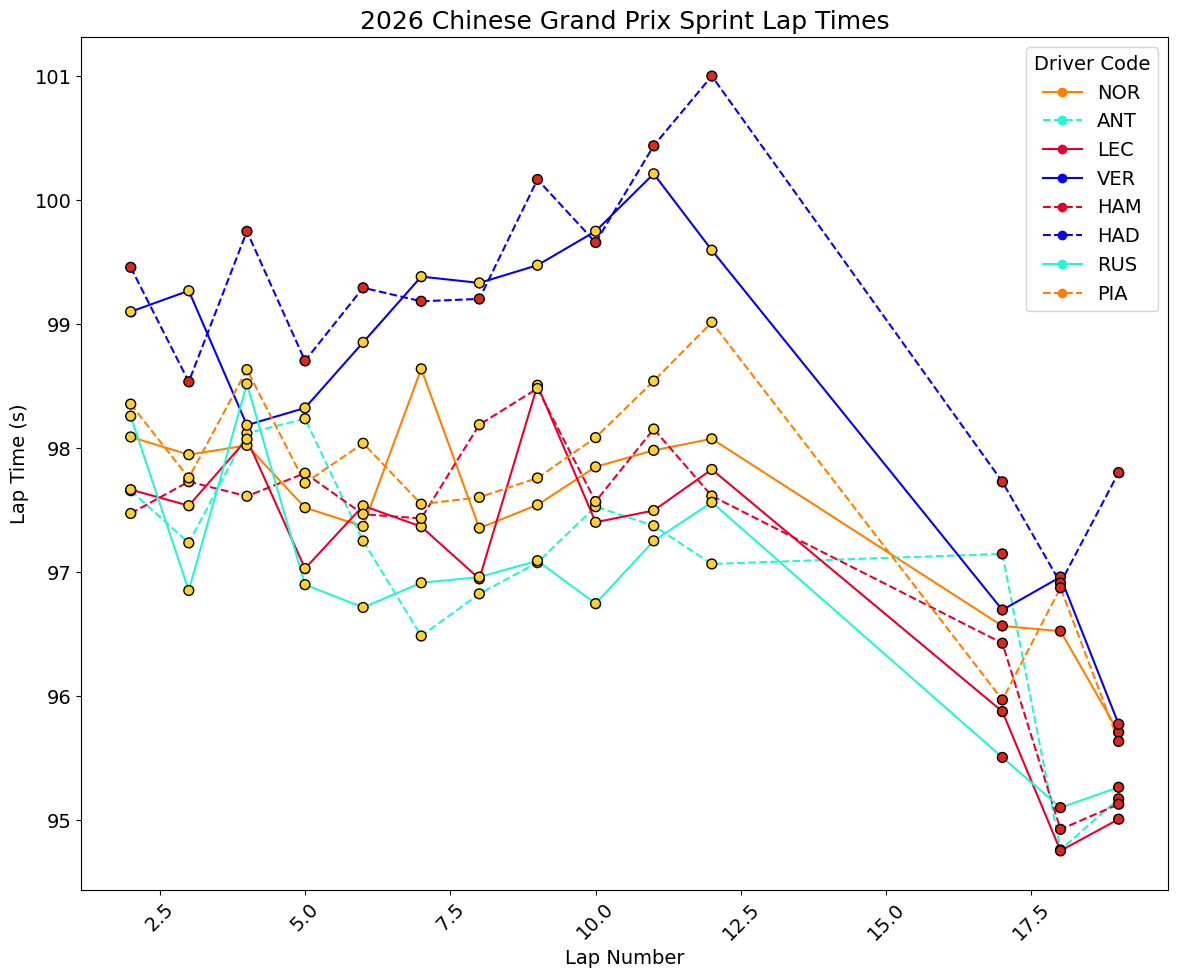

In [36]:
SPRINT_LAPS = S.laps.pick_quicklaps()
SPRINT_LAPS["LapTime"] = pd.to_timedelta(SPRINT_LAPS["LapTime"], errors="coerce")
SPRINT_LAPS["lapTimeSeconds"] = SPRINT_LAPS["LapTime"].dt.total_seconds()
sprint_laps = sqldf("SELECT * FROM SPRINT_LAPS WHERE Driver IN ('RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'PIA', 'VER', 'HAD')")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for driver in sprint_laps['Driver'].unique():
    driver_data = sprint_laps[sprint_laps['Driver'] == driver]
    color = PALETTE_DRIVERS[driver]
    style = DRIVER_STYLES[driver]
    marker_colors = [COMPOUND_COLORS.get(c, '#808080') for c in driver_data['Compound']]

    ax.plot(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        label = driver,
        color = color, 
        linestyle = style, 
        marker = 'o'
        )
    
    ax.scatter(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        c = marker_colors, 
        edgecolors = 'black', # Makes the dots pop
        s = 50, 
        zorder = 3
    )

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time (s)")
ax.set_title(f'{SEASON} ' + str(RACE.event['EventName']) + " Sprint Lap Times", fontsize=18)
ax.legend(title="Driver Code")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

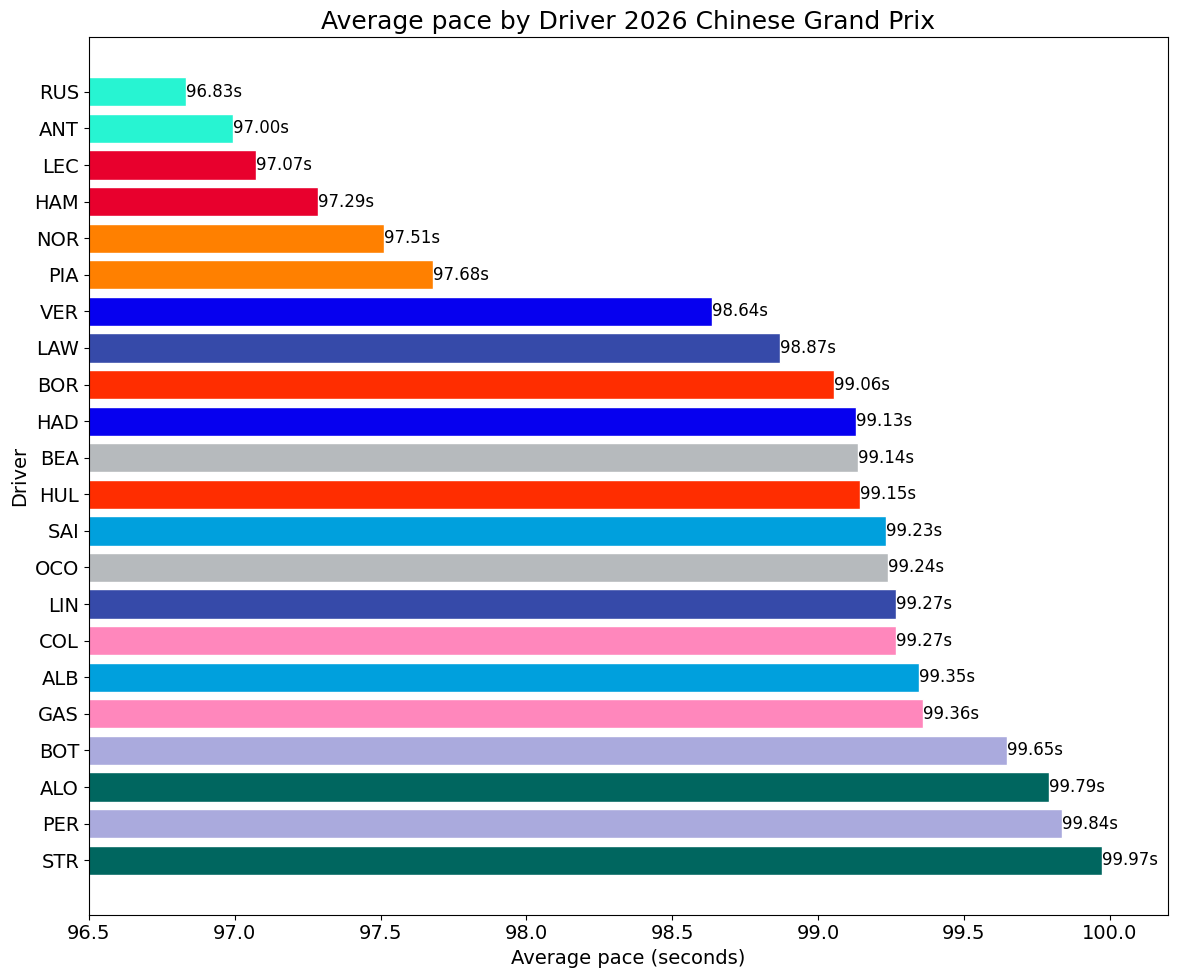

In [43]:
AVERAGE_PACE = SPRINT_LAPS.groupby("Driver")["lapTimeSeconds"].mean().reset_index()
AVERAGE_PACE = AVERAGE_PACE.rename(columns={"lapTimeSeconds": "avgPace"})
AVERAGE_PACE = AVERAGE_PACE.sort_values("avgPace", ascending=False)

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(
    AVERAGE_PACE['Driver'],
    AVERAGE_PACE['avgPace'],
    color=[PALETTE_DRIVERS[driver] for driver in AVERAGE_PACE['Driver']],
    edgecolor='white'
)

ax.set_xlim(96.5, 100.2)

for index, (driver, avg_time) in enumerate(zip(AVERAGE_PACE['Driver'], AVERAGE_PACE['avgPace'])):
    ax.text(avg_time, index, f"{avg_time:.2f}s", va='center', ha='left', color='black', fontsize=12)

ax.set_xlabel('Average pace (seconds)')
ax.set_ylabel('Driver')
ax.set_title(f'Average pace by Driver {SEASON} ' + str(S.event['EventName']), fontsize=18)

plt.tight_layout()
plt.show()

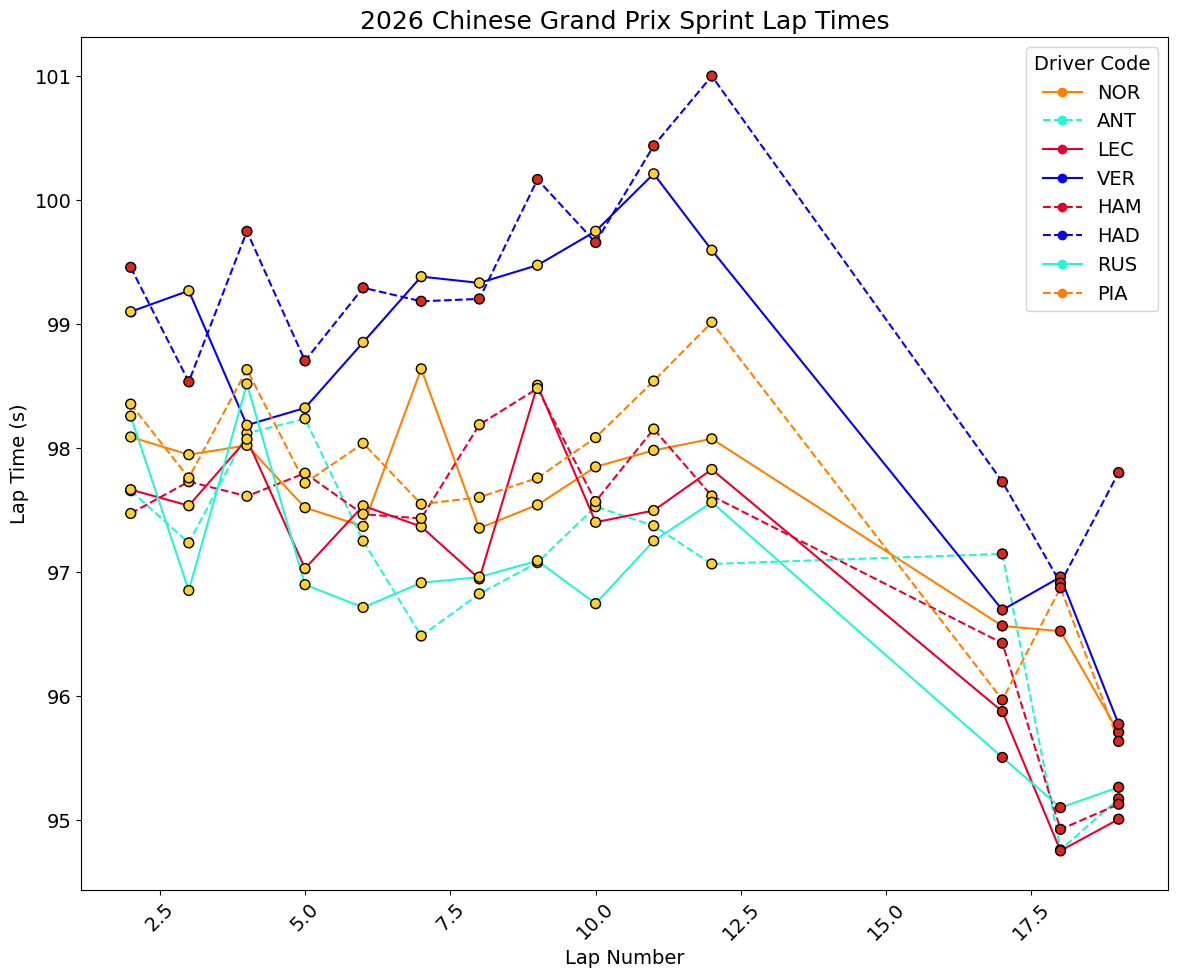

In [46]:
SPRINT_LAPS = S.laps.pick_quicklaps()
SPRINT_LAPS["LapTime"] = pd.to_timedelta(SPRINT_LAPS["LapTime"], errors="coerce")
SPRINT_LAPS["lapTimeSeconds"] = SPRINT_LAPS["LapTime"].dt.total_seconds()
sprint_laps = sqldf("SELECT * FROM SPRINT_LAPS WHERE Driver IN ('RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'PIA', 'VER', 'HAD')")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for driver in sprint_laps['Driver'].unique():
    driver_data = sprint_laps[sprint_laps['Driver'] == driver]
    color = PALETTE_DRIVERS[driver]
    style = DRIVER_STYLES[driver]
    marker_colors = [COMPOUND_COLORS.get(c, '#808080') for c in driver_data['Compound']]

    ax.plot(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        label = driver,
        color = color, 
        linestyle = style, 
        marker = 'o'
        )
    
    ax.scatter(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        c = marker_colors, 
        edgecolors = 'black', # Makes the dots pop
        s = 50, 
        zorder = 3
    )

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time (s)")
ax.set_title(f'{SEASON} ' + str(RACE.event['EventName']) + " Sprint Lap Times", fontsize=18)
ax.legend(title="Driver Code")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# qualifying

In [47]:
Q.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,1.0,,NaN,0 days 00:01:33.305000,0 days 00:01:32.443000,0 days 00:01:32.064000,NaT,,NaN,NaN
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,2.0,,NaN,0 days 00:01:33.262000,0 days 00:01:32.523000,0 days 00:01:32.286000,NaT,,NaN,NaN
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,3.0,,NaN,0 days 00:01:33.522000,0 days 00:01:32.567000,0 days 00:01:32.415000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,4.0,,NaN,0 days 00:01:33.175000,0 days 00:01:32.486000,0 days 00:01:32.428000,NaT,,NaN,NaN
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,5.0,,NaN,0 days 00:01:33.590000,0 days 00:01:33.130000,0 days 00:01:32.550000,NaT,,NaN,NaN
1,1,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,6.0,,NaN,0 days 00:01:33.535000,0 days 00:01:32.910000,0 days 00:01:32.608000,NaT,,NaN,NaN
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,7.0,,NaN,0 days 00:01:33.788000,0 days 00:01:33.003000,0 days 00:01:32.873000,NaT,,NaN,NaN
3,3,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,8.0,,NaN,0 days 00:01:33.417000,0 days 00:01:33.098000,0 days 00:01:33.002000,NaT,,NaN,NaN
6,6,I HADJAR,HAD,hadjar,Red Bull Racing,4781D7,red_bull,Isack,Hadjar,Isack Hadjar,...,9.0,,NaN,0 days 00:01:33.632000,0 days 00:01:33.352000,0 days 00:01:33.121000,NaT,,NaN,NaN
87,87,O BEARMAN,BEA,bearman,Haas F1 Team,9C9FA2,haas,Oliver,Bearman,Oliver Bearman,...,10.0,,NaN,0 days 00:01:33.687000,0 days 00:01:33.197000,0 days 00:01:33.292000,NaT,,NaN,NaN


In [48]:
Q_RESULTS = Q.results
Q_RESULTS = Q_RESULTS[["Abbreviation", "Position", "Q1", "Q2", "Q3"]]
Q_RESULTS = sqldf(
    """
    SELECT "Abbreviation", "Position", CASE WHEN Position BETWEEN 1 AND 10 THEN Q3 WHEN Position BETWEEN 11 AND 15 THEN Q2 ELSE Q1 END AS Time
    FROM Q_RESULTS
    """
)
Q_RESULTS['Time'] = pd.to_timedelta(Q_RESULTS['Time'])
Q_RESULTS["LapTime"] = Q_RESULTS["Time"].dt.total_seconds()
Q_RESULTS

,Abbreviation,Position,Time,LapTime
0,ANT,1.0,0 days 00:01:32.064000,92.064
1,RUS,2.0,0 days 00:01:32.286000,92.286
2,HAM,3.0,0 days 00:01:32.415000,92.415
3,LEC,4.0,0 days 00:01:32.428000,92.428
4,PIA,5.0,0 days 00:01:32.550000,92.550
5,NOR,6.0,0 days 00:01:32.608000,92.608
6,GAS,7.0,0 days 00:01:32.873000,92.873
7,VER,8.0,0 days 00:01:33.002000,93.002
8,HAD,9.0,0 days 00:01:33.121000,93.121
9,BEA,10.0,0 days 00:01:33.292000,93.292


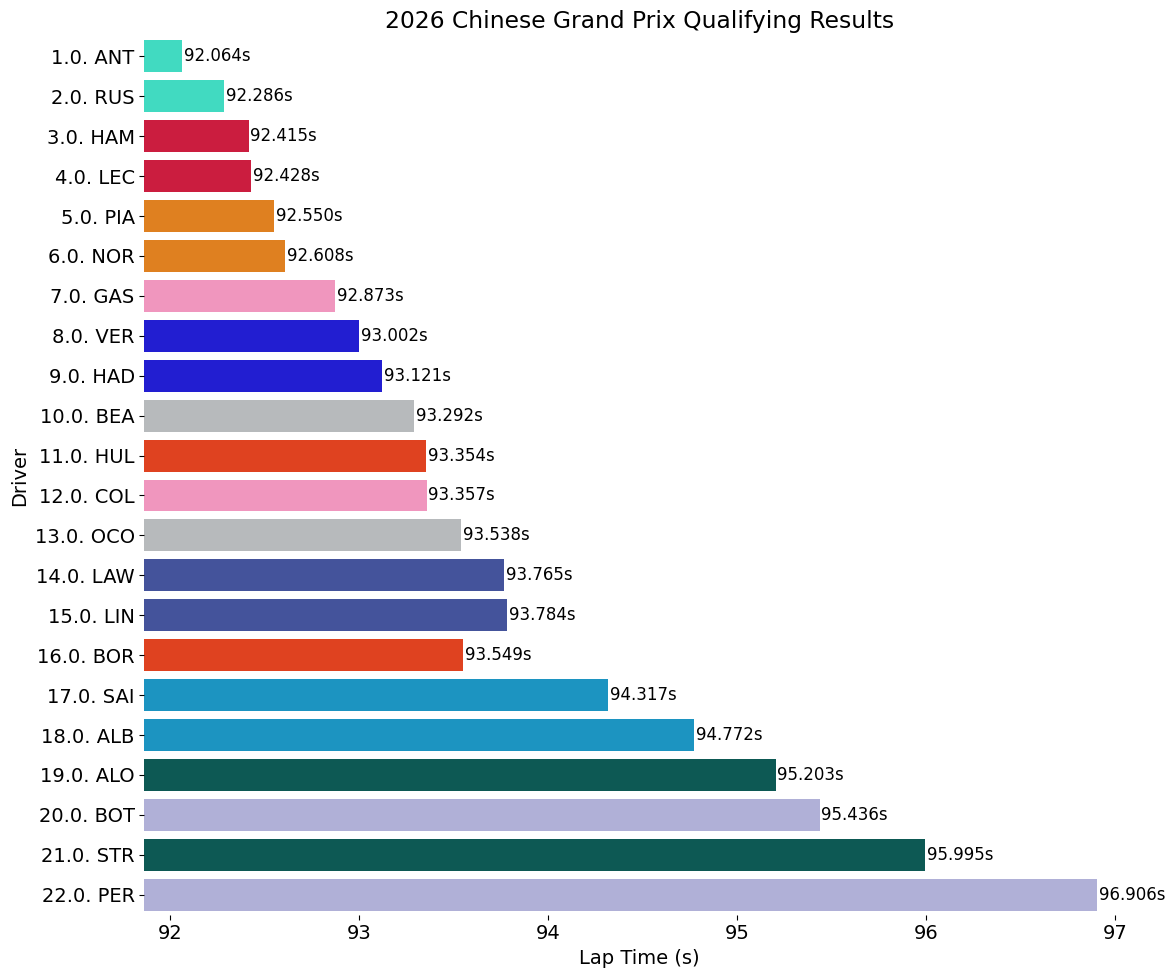

In [49]:
Q_RESULTS['Position_Abbreviation'] = Q_RESULTS['Position'].astype(str) + '. ' + Q_RESULTS['Abbreviation']

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

sns.barplot(data=Q_RESULTS,
            y='Position_Abbreviation', 
            x='LapTime',
            hue='Abbreviation', 
            dodge=False,
            palette=PALETTE_DRIVERS, 
            ax=ax
            )

for index, row in Q_RESULTS.iterrows():
    ax.text(row['LapTime'] + 0.01, index, f'{row["LapTime"]:.3f}s', va='center', fontsize=12)

ax.set_xlim(Q_RESULTS['LapTime'].min() - 0.2, Q_RESULTS['LapTime'].max() + 0.2)
ax.set_xlabel("Lap Time (s)")
ax.set_ylabel("Driver")
ax.set_title(f"{SEASON} {RACE.event['EventName']} Qualifying Results")

sns.despine(left=True, bottom=True)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

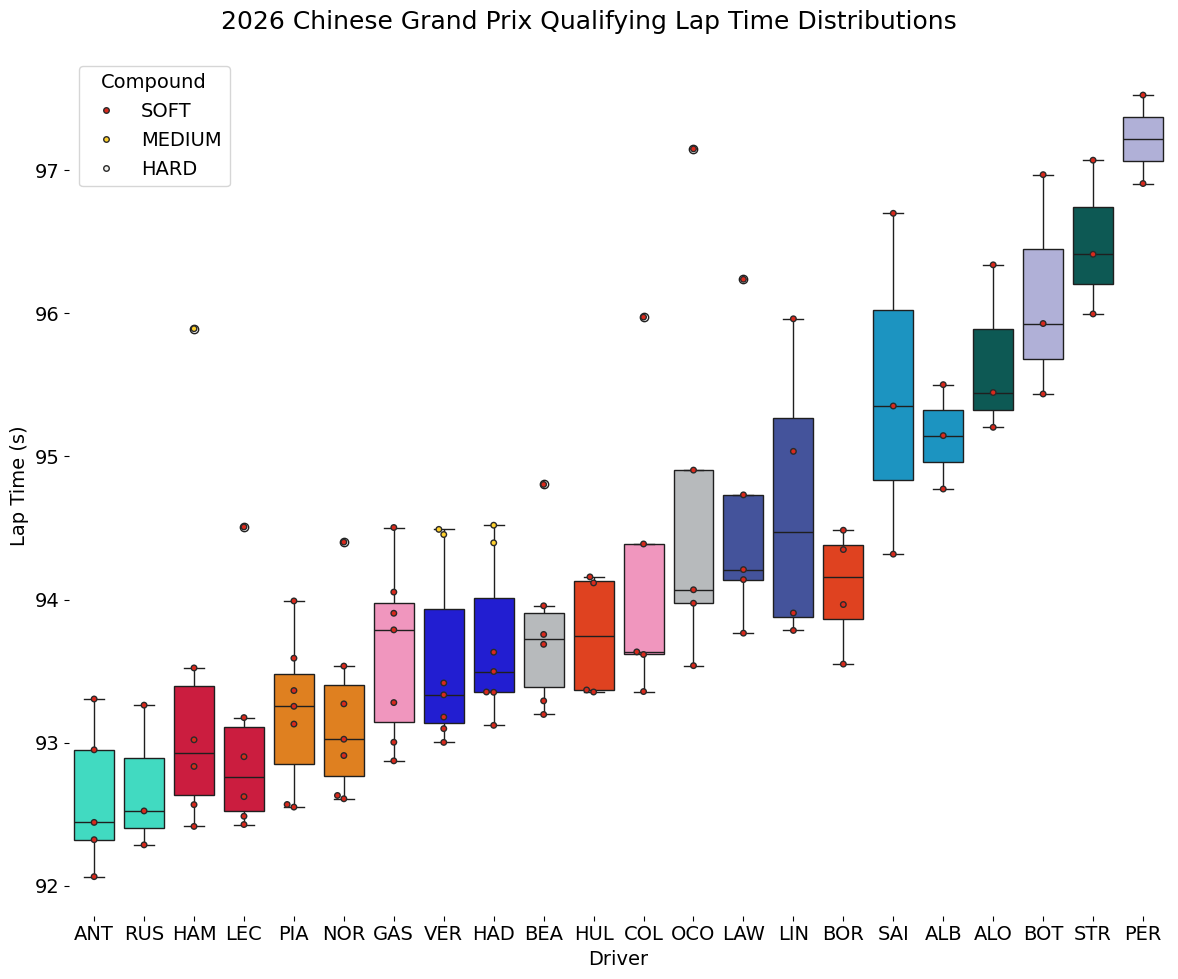

In [50]:
Q_LAPS = Q.laps.pick_quicklaps()
Q_LAPS["LapTime"] = pd.to_timedelta(Q_LAPS["LapTime"], errors="coerce")
Q_LAPS["LapTime"] = Q_LAPS["LapTime"].dt.total_seconds()

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

sns.boxplot(data=Q_LAPS,
            x="Driver",
            y="LapTime",
            hue="Driver",
            order=Q_RESULTS["Abbreviation"],
            palette=PALETTE_DRIVERS
            )

sns.swarmplot(data=Q_LAPS,
              x="Driver",   
              y="LapTime",
              hue="Compound",
              palette=COMPOUND_COLORS,
              hue_order=["SOFT", "MEDIUM", "HARD"],
              linewidth=1,
              size=4,
              )

ax.set_xlabel("Driver")
ax.set_ylabel("Lap Time (s)")
plt.suptitle(f"{SEASON} " + str(RACE.event['EventName']) + " Qualifying Lap Time Distributions", fontsize=18)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

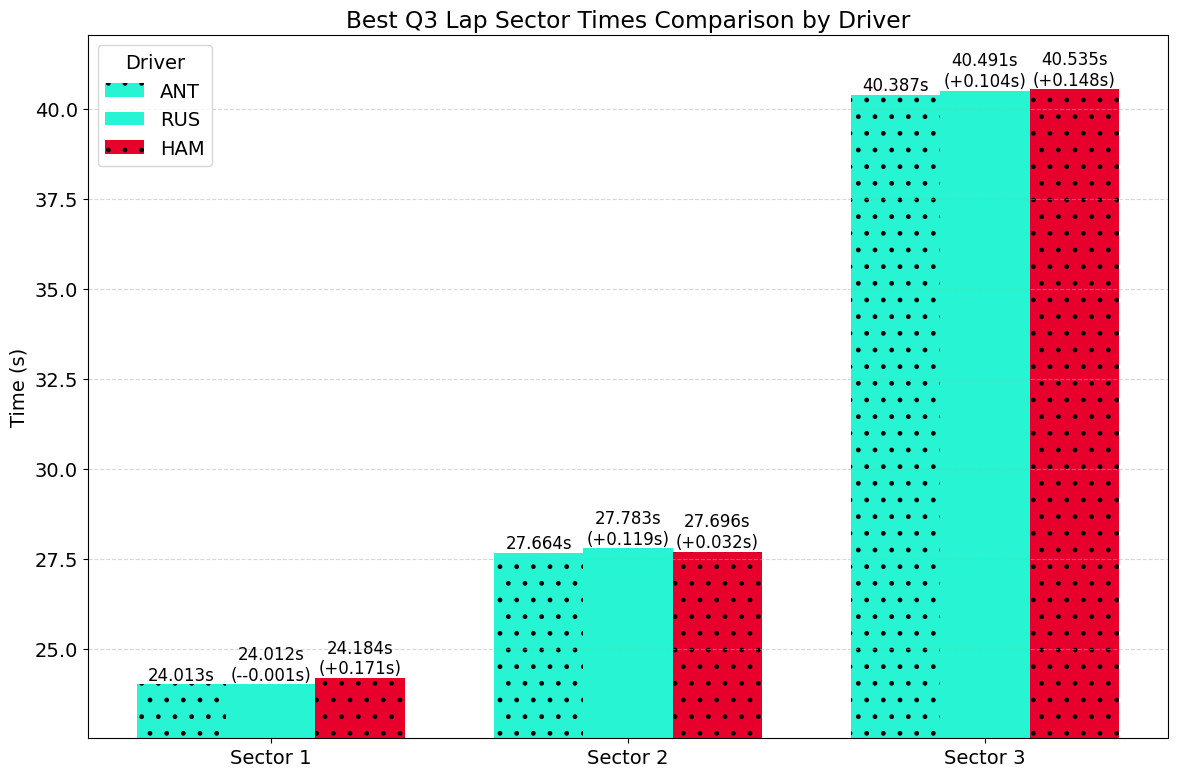

In [52]:
SECTOR_COMP = sqldf(
    """
    SELECT Q_RESULTS.Position, Q_LAPS.Driver, Q_LAPS.Sector1Time, Q_LAPS.Sector2Time, Q_LAPS.Sector3Time
    FROM Q_RESULTS
    JOIN Q_LAPS ON Q_RESULTS.Abbreviation = Q_LAPS.DRIVER AND Q_RESULTS.LapTime = Q_LAPS.LapTime
    WHERE Q_RESULTS.Position BETWEEN 1 AND 3
    ORDER BY Q_RESULTS.Position
    """
)

SECTOR_COMP["Sector1Time"] = pd.to_timedelta(SECTOR_COMP["Sector1Time"], errors="coerce")
SECTOR_COMP["Sector2Time"] = pd.to_timedelta(SECTOR_COMP["Sector2Time"], errors="coerce")
SECTOR_COMP["Sector3Time"] = pd.to_timedelta(SECTOR_COMP["Sector3Time"], errors="coerce")

SECTOR_LONG = SECTOR_COMP.melt(id_vars=['Driver','Position'],
                                value_vars=['Sector1Time', 'Sector2Time', 'Sector3Time'],
                                var_name='Sector',
                                value_name='Time'
                                )

SECTOR_LONG['Sector'] = SECTOR_LONG['Sector'].str.replace('Sector', 'Sector ', regex=False)
SECTOR_LONG['TimeSeconds'] = SECTOR_LONG['Time'].dt.total_seconds()

SECTOR_LONG_1 = sqldf("SELECT * FROM SECTOR_LONG WHERE Position = 1")
SECTOR_LONG = sqldf(
    """
    SELECT A.*, CASE WHEN A.TimeSeconds - B.TimeSeconds > 0 THEN concat('+', round(A.TimeSeconds - B.TimeSeconds, 3)) ELSE concat('-', round(A.TimeSeconds - B.TimeSeconds, 3)) END AS Difference
    FROM SECTOR_LONG A
    JOIN SECTOR_LONG_1 B ON A.Sector = B.Sector
    """
)

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 8))

SECTORS = ['Sector 1', 'Sector 2', 'Sector 3']
x = np.arange(len(SECTORS))
bar_width = 0.25

# Plot each driver's sector times
for i, driver in enumerate(SECTOR_LONG['Driver'].unique()):
    driver_data = SECTOR_LONG[SECTOR_LONG['Driver'] == driver].sort_values('Sector')
    times = driver_data['TimeSeconds'].values
    diffs = driver_data['Difference'].values
    positions = driver_data['Position'].values
    bars = ax.bar(x + i * bar_width,
           times,
           width=bar_width,
           label=driver,
           color=PALETTE_DRIVERS[driver],
           hatch='.' if DRIVER_STYLES[driver] == 'dashed' else ''
           )
    for j, time in enumerate(times):
        if positions[j] == 1:
            label_text = f'{time:.3f}s'
        else:
            label_text = f'{time:.3f}s\n({diffs[j]}s)'
        
        ax.text(x[j] + i * bar_width,
                time + 0.02,
                label_text,
                ha='center',
                va='bottom',
                fontsize=12)

# Ticks and labels
ax.set_xticks(x + bar_width)
ax.set_xticklabels(SECTORS)
ax.set_ylabel("Time (s)")
y_min = SECTOR_LONG['TimeSeconds'].min() - 1.5
y_max = SECTOR_LONG['TimeSeconds'].max() + 1.5
ax.set_ylim(y_min, y_max)
ax.set_title("Best Q3 Lap Sector Times Comparison by Driver")
ax.legend(title="Driver")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
# CIRCUIT_INFO = Q.get_circuit_info()

# DRIVER_1 = 'RUS'
# DRIVER_2 = 'ANT'
# DRIVER_3 = 'HAD'

# DRIVER_1_LAP = Q_LAPS.pick_driver(DRIVER_1).pick_fastest()
# DRIVER_1_TEL = DRIVER_1_LAP.get_car_data().add_distance()
# DRIVER_1_TEL["Time"] = pd.to_timedelta(DRIVER_1_TEL["Time"], errors="coerce")
# DRIVER_2_LAP = Q_LAPS.pick_driver(DRIVER_2).pick_fastest()
# DRIVER_2_TEL = DRIVER_2_LAP.get_car_data().add_distance()
# DRIVER_2_TEL["Time"] = pd.to_timedelta(DRIVER_2_TEL["Time"], errors="coerce")
# DRIVER_3_LAP = Q_LAPS.pick_driver(DRIVER_3).pick_fastest()
# DRIVER_3_TEL = DRIVER_3_LAP.get_car_data().add_distance()
# DRIVER_3_TEL["Time"] = pd.to_timedelta(DRIVER_3_TEL["Time"], errors="coerce")

# plt.style.use('default')
# plt.rcParams.update({'font.size': 14})
# fig, ax = plt.subplots(figsize=(12, 10))

# ax.vlines(
#     x = CIRCUIT_INFO.corners['Distance'], 
#     ymin = DRIVER_1_TEL["Speed"].min(), 
#     ymax = DRIVER_1_TEL["Speed"].max(), 
#     linestyles = 'dotted', 
#     colors = 'black'
#     )

# for _, corner in CIRCUIT_INFO.corners.iterrows():
#     txt = f"{corner['Number']}{corner['Letter']}"
#     ax.text(
#         corner['Distance'], 
#         DRIVER_1_TEL['Speed'].min() - 0.5,
#         txt, va='center_baseline', ha='center', size='small'
#     )

# ax.plot(DRIVER_1_TEL['Distance'], DRIVER_1_TEL['Speed'], color = PALETTE_TEAMS["McLaren"], linestyle = DRIVER_STYLES[DRIVER_1], label = DRIVER_1)
# ax.plot(DRIVER_2_TEL['Distance'], DRIVER_2_TEL['Speed'], color = PALETTE_TEAMS["McLaren"], linestyle = DRIVER_STYLES[DRIVER_2], label = DRIVER_2)
# ax.plot(DRIVER_3_TEL['Distance'], DRIVER_3_TEL['Speed'], color = PALETTE_TEAMS["Red Bull"], linestyle = DRIVER_STYLES[DRIVER_3], label = DRIVER_3)

# ax.set_xlabel('Distance in m')
# ax.set_ylabel('Speed in km/h')

# fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax.transAxes, ncol=6)

# plt.suptitle(f"Fastest Lap Comparison " f"{Q.event['EventName']} {Q.event.year} Qualifying")

# plt.tight_layout()
# plt.show()

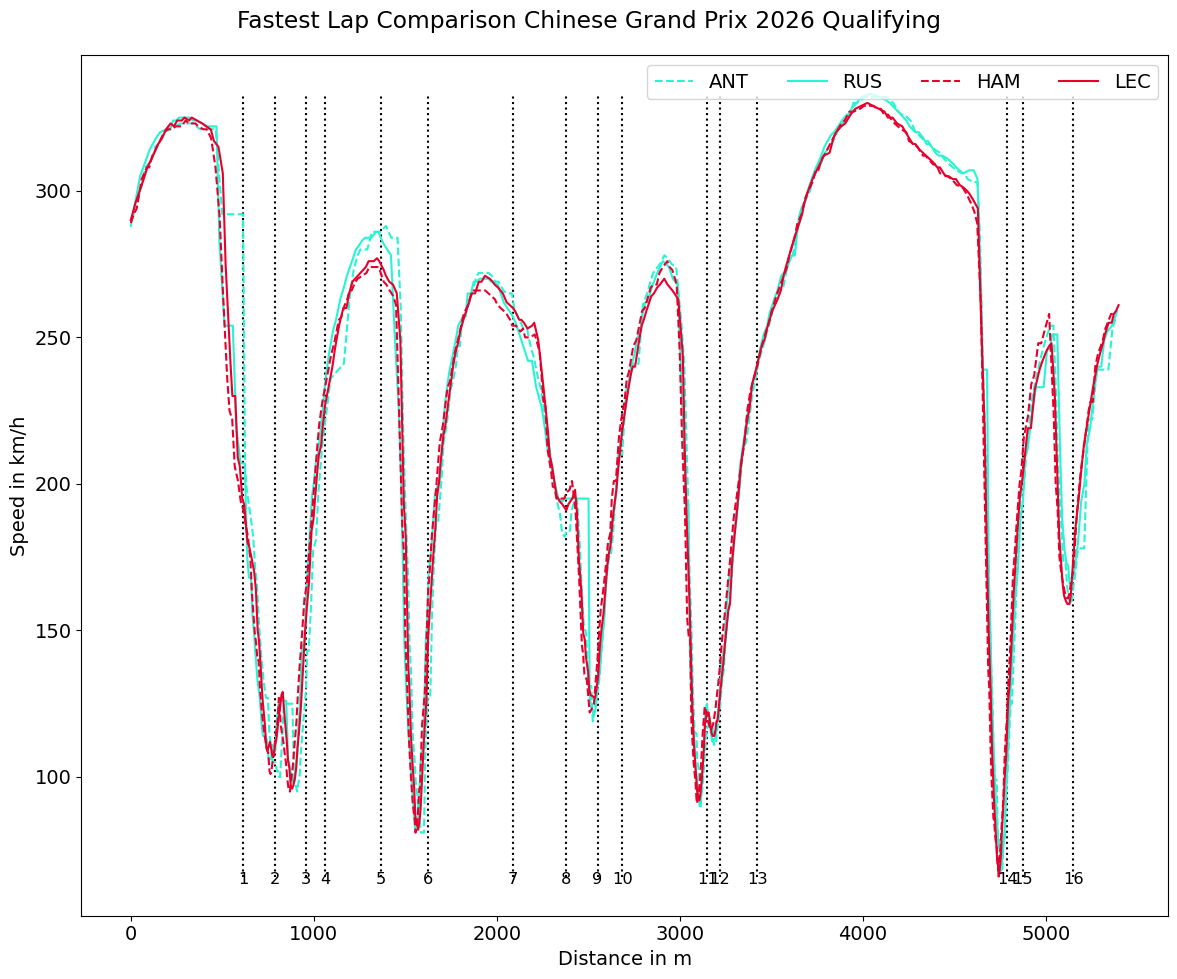

In [54]:
from urllib.request import urlopen
import json

COUNTRY = "China"

# GET SESSION NUMBER
BASE_URL = f"https://api.openf1.org/v1/sessions?year={SEASON}&country_name={COUNTRY}"
response = urlopen(BASE_URL)
data = json.loads(response.read().decode('utf-8'))
sessions = pd.DataFrame(data)
SESSION_KEY = int(sessions.loc[sessions['session_name'] == 'Qualifying', 'session_key'].iloc[0])

# GET BEST 4 DRIVERS IN QUALI
Q_DRIVER_1 = int(Q.results.loc[Q.results['Position'] == 1, 'DriverNumber'].iloc[0])
Q_DRIVER_2 = int(Q.results.loc[Q.results['Position'] == 2, 'DriverNumber'].iloc[0])
Q_DRIVER_3 = int(Q.results.loc[Q.results['Position'] == 3, 'DriverNumber'].iloc[0])
Q_DRIVER_4 = int(Q.results.loc[Q.results['Position'] == 4, 'DriverNumber'].iloc[0])

params = {
    'session_key': SESSION_KEY,
    'driver_number': [Q_DRIVER_1, Q_DRIVER_2, Q_DRIVER_3, Q_DRIVER_4]
}

# GET TELEMETRY DATA
response = requests.get("https://api.openf1.org/v1/car_data", params=params)
data = response.json()
car_data = pd.DataFrame(data)
car_data['date'] = pd.to_datetime(car_data['date'], format='ISO8601')

# GET BEST LAPS FROM EACH TO KNOW WHEN THEY STARTED
response = requests.get("https://api.openf1.org/v1/laps", params=params)
data = response.json()
laps = pd.DataFrame(data)
best_times_df = (laps.groupby('driver_number')['lap_duration']
                 .min()
                 .reset_index(name='best_time'))

best_laps = pd.merge(laps, best_times_df, left_on = ['driver_number', 'lap_duration'], right_on = ['driver_number', 'best_time'])
best_laps['date_start'] = pd.to_datetime(best_laps['date_start'])
best_laps['lap_duration'] = pd.to_timedelta(best_laps['lap_duration'], unit='s')
best_laps['date_end'] = best_laps['date_start'] + best_laps['lap_duration']
best_laps = best_laps[['driver_number', 'date_start', 'lap_duration', 'date_end']]

# CROSS INFO: TELEMETRY X BEST LAPS
telemetry = sqldf(
    """
    SELECT c.*
    FROM car_data c
    JOIN best_laps l ON c.driver_number = l.driver_number AND c.date BETWEEN l.date_start AND l.date_end
    """
)

# DRIVERS
response = requests.get("https://api.openf1.org/v1/drivers", params=params)
data = response.json()
drivers = pd.DataFrame(data)
drivers = drivers[['driver_number', 'name_acronym']].drop_duplicates()

# CROSS INFO: TELEMETRY X DRIVERS
telemetry = pd.merge(telemetry, drivers, left_on = ['driver_number'], right_on = ['driver_number'])

# CALCULATE DISTANCE
telemetry['date'] = pd.to_datetime(telemetry['date'])
telemetry = telemetry.sort_values(by=['driver_number', 'date'])
telemetry['dt'] = telemetry.groupby('driver_number')['date'].diff().dt.total_seconds().fillna(0)
telemetry['speed_ms'] = telemetry['speed'] / 3.6
telemetry['dist_inc'] = telemetry['speed_ms'] * telemetry['dt']
telemetry['distance'] = telemetry.groupby('driver_number')['dist_inc'].cumsum()

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

CIRCUIT_INFO = Q.get_circuit_info()

for _, corner in CIRCUIT_INFO.corners.iterrows():
    txt = f"{corner['Number']}{corner['Letter']}"
    ax.text(
        corner['Distance'], 
        telemetry['speed'].min() - 0.5,
        txt, va='center_baseline', ha='center', size='small'
    )

ax.vlines(
    x = CIRCUIT_INFO.corners['Distance'], 
    ymin = telemetry["speed"].min(), 
    ymax = telemetry["speed"].max(), 
    linestyles = 'dotted', 
    colors = 'black'
    )

driver_1_tel = telemetry[telemetry['driver_number'] == Q_DRIVER_1]
driver_2_tel = telemetry[telemetry['driver_number'] == Q_DRIVER_2]
driver_3_tel = telemetry[telemetry['driver_number'] == Q_DRIVER_3]
driver_4_tel = telemetry[telemetry['driver_number'] == Q_DRIVER_4]

ax.plot(driver_1_tel['distance'], driver_1_tel['speed'], color = PALETTE_DRIVERS[driver_1_tel['name_acronym'].iloc[0]], linestyle = DRIVER_STYLES[driver_1_tel['name_acronym'].iloc[0]], label = driver_1_tel['name_acronym'].iloc[0])
ax.plot(driver_2_tel['distance'], driver_2_tel['speed'], color = PALETTE_DRIVERS[driver_2_tel['name_acronym'].iloc[0]], linestyle = DRIVER_STYLES[driver_2_tel['name_acronym'].iloc[0]], label = driver_2_tel['name_acronym'].iloc[0])
ax.plot(driver_3_tel['distance'], driver_3_tel['speed'], color = PALETTE_DRIVERS[driver_3_tel['name_acronym'].iloc[0]], linestyle = DRIVER_STYLES[driver_3_tel['name_acronym'].iloc[0]], label = driver_3_tel['name_acronym'].iloc[0])
ax.plot(driver_4_tel['distance'], driver_4_tel['speed'], color = PALETTE_DRIVERS[driver_4_tel['name_acronym'].iloc[0]], linestyle = DRIVER_STYLES[driver_4_tel['name_acronym'].iloc[0]], label = driver_4_tel['name_acronym'].iloc[0])

ax.set_xlabel('Distance in m')
ax.set_ylabel('Speed in km/h')

fig.legend(loc = 'upper right', bbox_to_anchor = (1, 1), bbox_transform = ax.transAxes, ncol = 6)

plt.suptitle(f"Fastest Lap Comparison " f"{Q.event['EventName']} {Q.event.year} Qualifying")

plt.tight_layout()
plt.show()

# race

In [55]:
RACE.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:33:15.607000,Finished,25.0,56.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:05.515000,Finished,18.0,56.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,3.0,3,3.0,NaT,NaT,NaT,0 days 00:00:25.267000,Finished,15.0,56.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,4.0,4,4.0,NaT,NaT,NaT,0 days 00:00:28.894000,Finished,12.0,56.0
87,87,O BEARMAN,BEA,bearman,Haas F1 Team,9C9FA2,haas,Oliver,Bearman,Oliver Bearman,...,5.0,5,10.0,NaT,NaT,NaT,0 days 00:00:57.268000,Finished,10.0,56.0
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,6.0,6,7.0,NaT,NaT,NaT,0 days 00:00:59.647000,Finished,8.0,56.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,7.0,7,14.0,NaT,NaT,NaT,0 days 00:01:20.588000,Finished,6.0,56.0
6,6,I HADJAR,HAD,hadjar,Red Bull Racing,4781D7,red_bull,Isack,Hadjar,Isack Hadjar,...,8.0,8,9.0,NaT,NaT,NaT,0 days 00:01:27.247000,Finished,4.0,56.0
55,55,C SAINZ,SAI,sainz,Williams,1868DB,williams,Carlos,Sainz,Carlos Sainz,...,9.0,9,17.0,NaT,NaT,NaT,0 days 00:00:11.673000,Lapped,2.0,55.0
43,43,F COLAPINTO,COL,colapinto,Alpine,00A1E8,alpine,Franco,Colapinto,Franco Colapinto,...,10.0,10,12.0,NaT,NaT,NaT,0 days 00:00:12.403000,Lapped,1.0,55.0


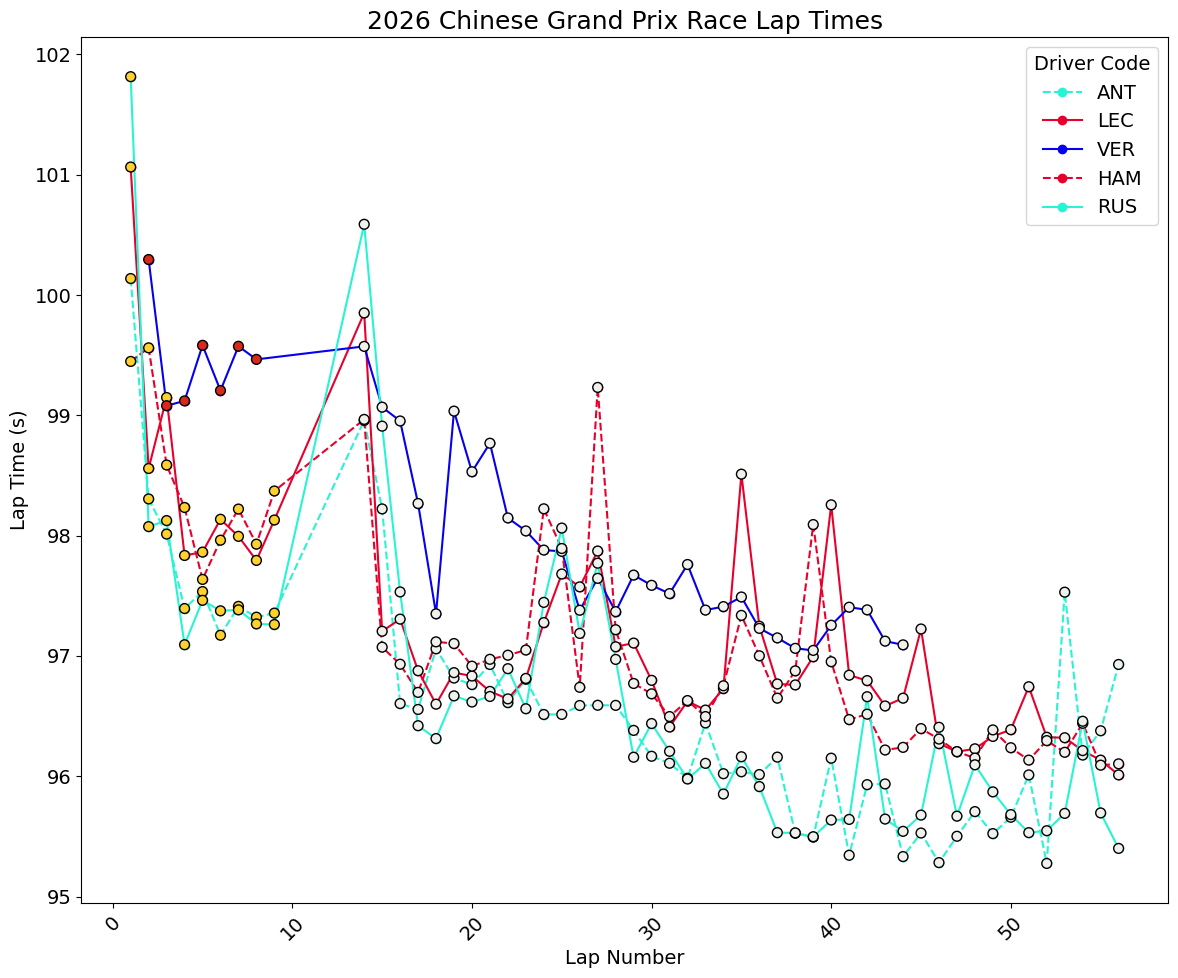

In [56]:
RACE_LAPS = RACE.laps.pick_quicklaps()
RACE_LAPS["LapTime"] = pd.to_timedelta(RACE_LAPS["LapTime"], errors="coerce")
RACE_LAPS["lapTimeSeconds"] = RACE_LAPS["LapTime"].dt.total_seconds()
race_laps = sqldf("SELECT * FROM RACE_LAPS WHERE Driver IN ('RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'VER')")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for driver in race_laps['Driver'].unique():
    driver_data = race_laps[race_laps['Driver'] == driver]
    color = PALETTE_DRIVERS[driver]
    style = DRIVER_STYLES[driver]
    marker_colors = [COMPOUND_COLORS.get(c, '#808080') for c in driver_data['Compound']]

    ax.plot(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        label = driver,
        color = color, 
        linestyle = style, 
        marker = 'o'
        )
    
    ax.scatter(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        c = marker_colors, 
        edgecolors = 'black', # Makes the dots pop
        s = 50, 
        zorder = 3
    )

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time (s)")
ax.set_title(f'{SEASON} ' + str(RACE.event['EventName']) + " Race Lap Times", fontsize=18)
ax.legend(title="Driver Code")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

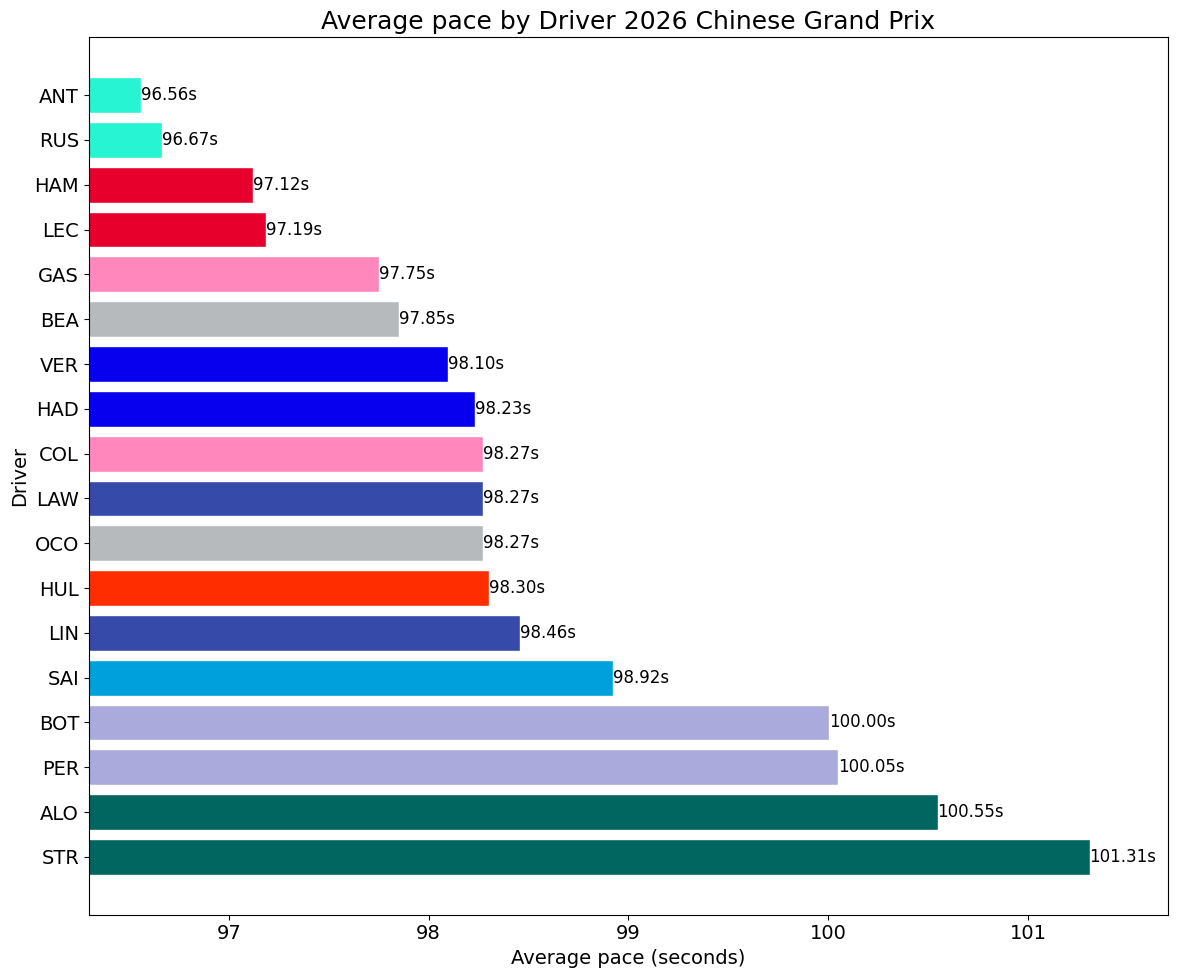

In [60]:
AVERAGE_PACE = RACE_LAPS.groupby("Driver")["lapTimeSeconds"].mean().reset_index()
AVERAGE_PACE = AVERAGE_PACE.rename(columns={"lapTimeSeconds": "avgPace"})
AVERAGE_PACE = AVERAGE_PACE.sort_values("avgPace", ascending=False)

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(
    AVERAGE_PACE['Driver'],
    AVERAGE_PACE['avgPace'],
    color=[PALETTE_DRIVERS[driver] for driver in AVERAGE_PACE['Driver']],
    edgecolor='white'
)

ax.set_xlim(96.3, 101.7)

for index, (driver, avg_time) in enumerate(zip(AVERAGE_PACE['Driver'], AVERAGE_PACE['avgPace'])):
    ax.text(avg_time, index, f"{avg_time:.2f}s", va='center', ha='left', color='black', fontsize=12)

ax.set_xlabel('Average pace (seconds)')
ax.set_ylabel('Driver')
ax.set_title(f'Average pace by Driver {SEASON} ' + str(RACE.event['EventName']), fontsize=18)

plt.tight_layout()
plt.show()

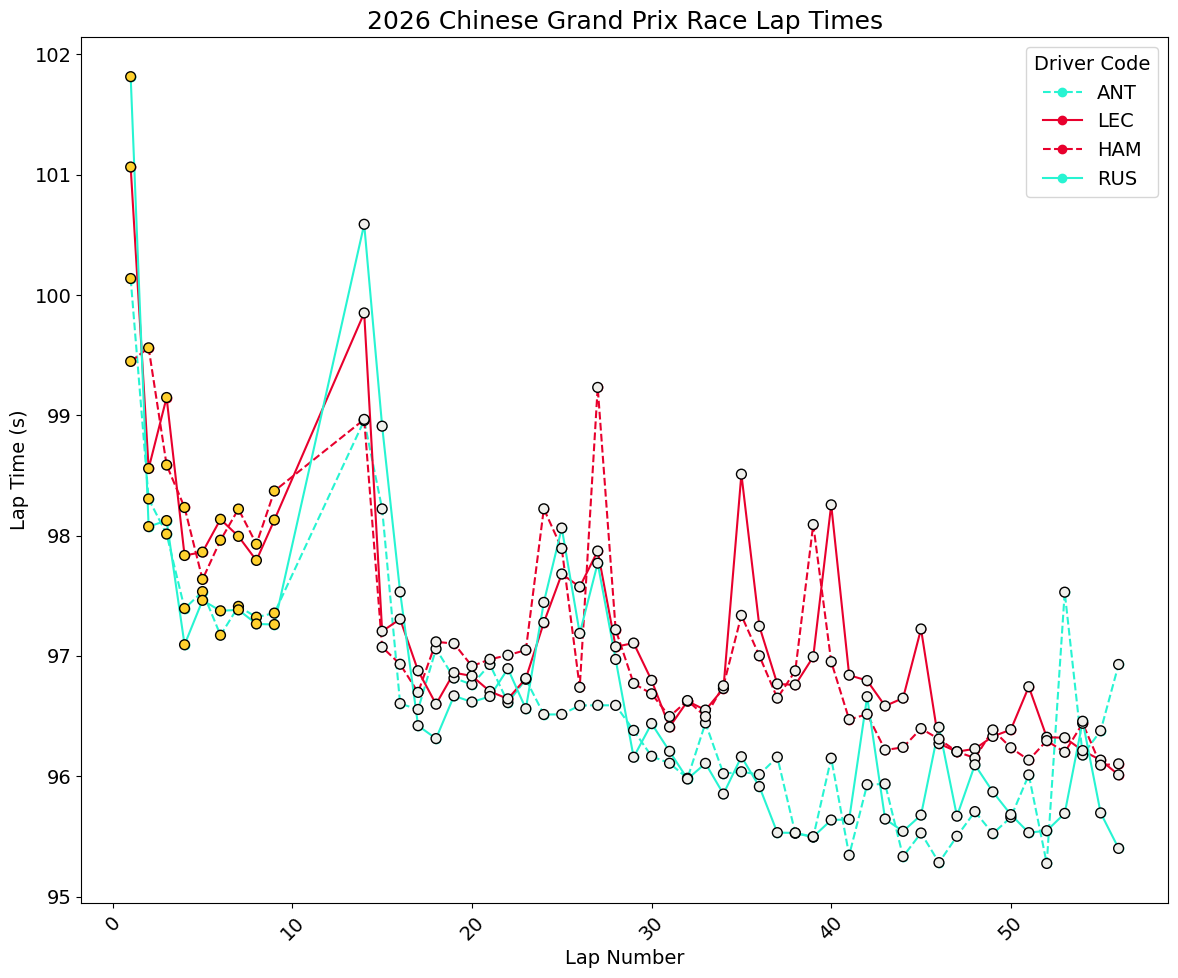

In [61]:
RACE_LAPS = RACE.laps.pick_quicklaps()
RACE_LAPS["LapTime"] = pd.to_timedelta(RACE_LAPS["LapTime"], errors="coerce")
RACE_LAPS["lapTimeSeconds"] = RACE_LAPS["LapTime"].dt.total_seconds()
race_laps = sqldf("SELECT * FROM RACE_LAPS WHERE Driver IN ('RUS', 'ANT', 'LEC', 'HAM')")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for driver in race_laps['Driver'].unique():
    driver_data = race_laps[race_laps['Driver'] == driver]
    color = PALETTE_DRIVERS[driver]
    style = DRIVER_STYLES[driver]
    marker_colors = [COMPOUND_COLORS.get(c, '#808080') for c in driver_data['Compound']]

    ax.plot(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        label = driver,
        color = color, 
        linestyle = style, 
        marker = 'o'
        )
    
    ax.scatter(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        c = marker_colors, 
        edgecolors = 'black', # Makes the dots pop
        s = 50, 
        zorder = 3
    )

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time (s)")
ax.set_title(f'{SEASON} ' + str(RACE.event['EventName']) + " Race Lap Times", fontsize=18)
ax.legend(title="Driver Code")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

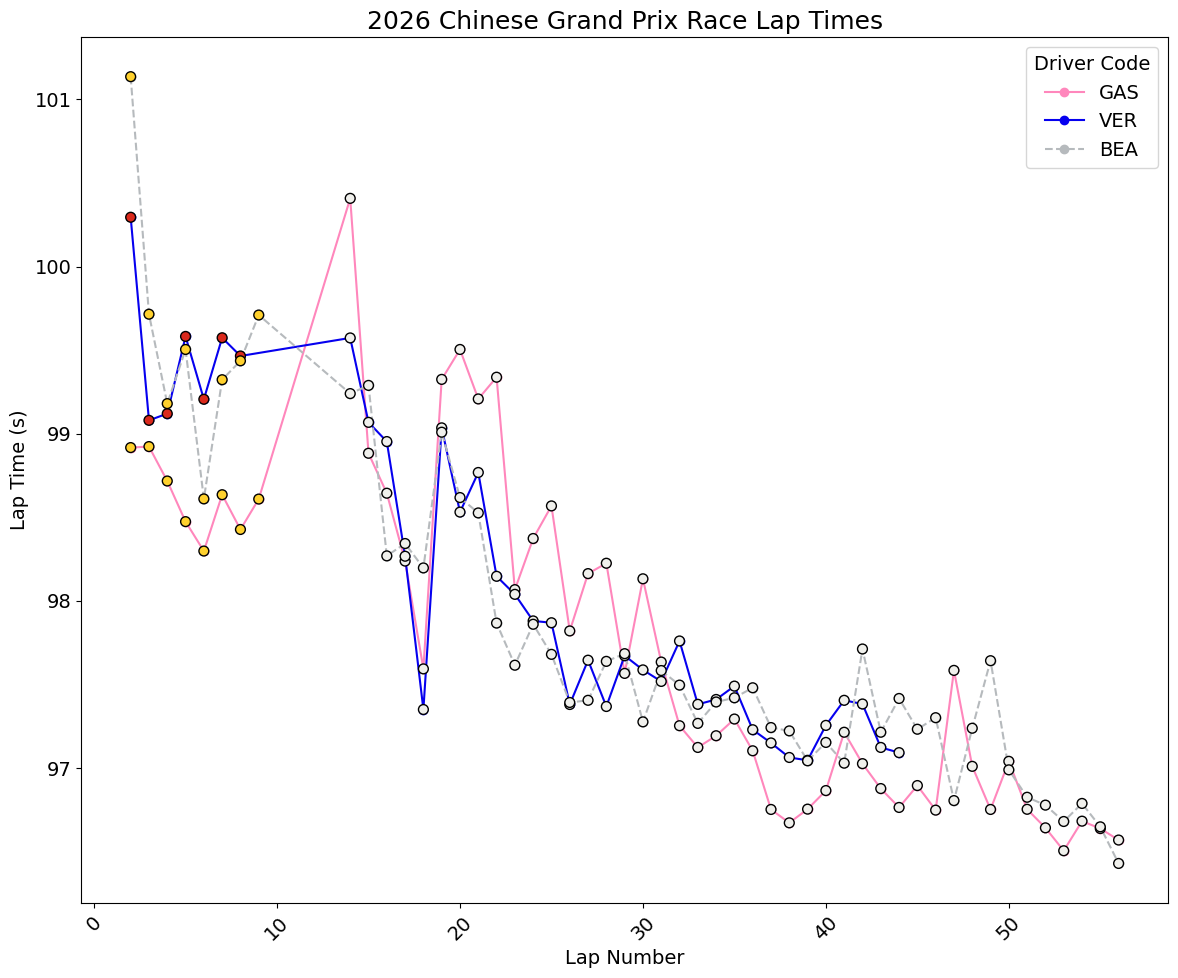

In [62]:
RACE_LAPS = RACE.laps.pick_quicklaps()
RACE_LAPS["LapTime"] = pd.to_timedelta(RACE_LAPS["LapTime"], errors="coerce")
RACE_LAPS["lapTimeSeconds"] = RACE_LAPS["LapTime"].dt.total_seconds()
race_laps = sqldf("SELECT * FROM RACE_LAPS WHERE Driver IN ('GAS', 'BEA', 'VER')")

plt.style.use('default')
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for driver in race_laps['Driver'].unique():
    driver_data = race_laps[race_laps['Driver'] == driver]
    color = PALETTE_DRIVERS[driver]
    style = DRIVER_STYLES[driver]
    marker_colors = [COMPOUND_COLORS.get(c, '#808080') for c in driver_data['Compound']]

    ax.plot(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        label = driver,
        color = color, 
        linestyle = style, 
        marker = 'o'
        )
    
    ax.scatter(
        driver_data['LapNumber'], 
        driver_data['lapTimeSeconds'], 
        c = marker_colors, 
        edgecolors = 'black', # Makes the dots pop
        s = 50, 
        zorder = 3
    )

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time (s)")
ax.set_title(f'{SEASON} ' + str(RACE.event['EventName']) + " Race Lap Times", fontsize=18)
ax.legend(title="Driver Code")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# championship races after the race

In [63]:
RESULTS = []

ROUNDS = range(1, ROUND_NUMBER + 1, 1)
SPRINTS = [2, 6, 7, 11, 14, 18]

for RND in ROUNDS:
    URL = f"http://api.jolpi.ca/ergast/f1/{SEASON}/{RND}/results.json"
    res = requests.get(URL)
    RESPONSE = res.json()
    races = RESPONSE['MRData']['RaceTable']['Races']
    RACE_RESULTS = races[0]['Results']
    TEMP = pd.json_normalize(RACE_RESULTS)
    TEMP['ROUND'] = RND
    TEMP = TEMP[['ROUND', 'Driver.code', 'Constructor.name', 'points']]
    RESULTS.append(TEMP)

    if RND in SPRINTS:
        URL = f"http://api.jolpi.ca/ergast/f1/{SEASON}/{RND}/sprint.json"
        res = requests.get(URL)
        RESPONSE = res.json()
        races = RESPONSE['MRData']['RaceTable']['Races']
        SPRINT_RESULTS = races[0]['SprintResults']
        TEMP = pd.json_normalize(SPRINT_RESULTS)
        TEMP['ROUND'] = RND
        TEMP = TEMP[['ROUND', 'Driver.code', 'Constructor.name', 'points']]
        RESULTS.append(TEMP)

RESULTS = pd.concat(RESULTS)
RESULTS = pd.DataFrame(RESULTS)
RESULTS.columns = ['ROUND', 'DRIVER_CODE', 'CONSTRUCTOR_NAME', 'POINTS']
RESULTS = sqldf(
    """ 
    SELECT R.*, GP.GRAND_PRIX_NAME
    FROM RESULTS R
    JOIN GRAND_PRIXS GP ON R.ROUND = GP.ROUND
    """
)
RESULTS['POINTS'] = pd.to_numeric(RESULTS['POINTS'], errors='coerce')
RESULTS = sqldf("SELECT ROUND, GRAND_PRIX_NAME, DRIVER_CODE, CONSTRUCTOR_NAME, sum(POINTS) AS POINTS FROM RESULTS GROUP BY ROUND, GRAND_PRIX_NAME, DRIVER_CODE, CONSTRUCTOR_NAME")
RESULTS['ACUM_POINTS'] = RESULTS.groupby(['DRIVER_CODE', 'CONSTRUCTOR_NAME'])['POINTS'].cumsum()
ACUM_RESULTS = RESULTS[['ROUND', 'DRIVER_CODE', 'CONSTRUCTOR_NAME', 'GRAND_PRIX_NAME', 'ACUM_POINTS']]

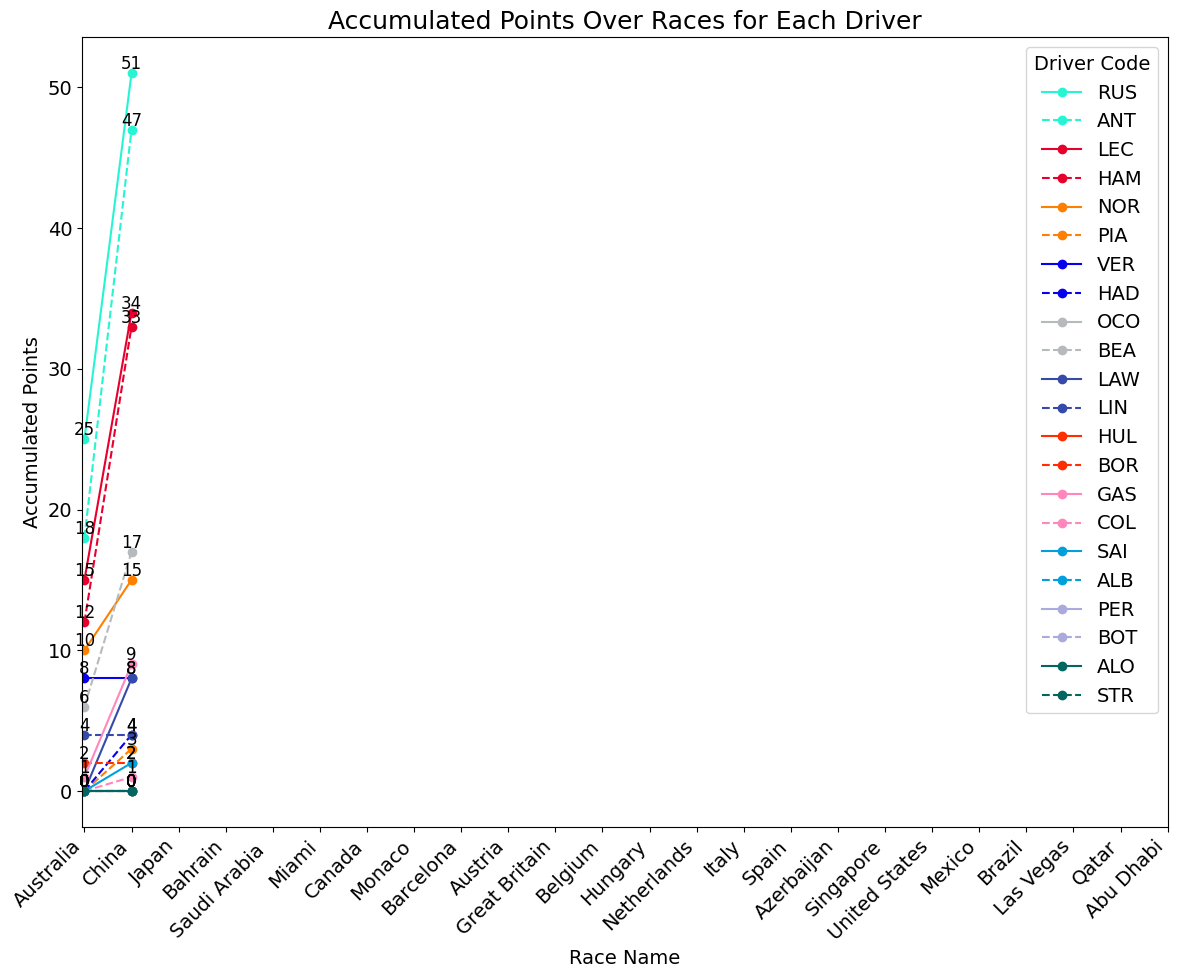

In [64]:
plt.style.use("default")
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for DRIVER in DRIVERS:
    DRIVER_DATA = RESULTS[RESULTS['DRIVER_CODE'] == DRIVER]
    DRIVER_FIRST_RACE = DRIVER_DATA[DRIVER_DATA['ROUND'] <= ROUND_NUMBER]

    ax.plot(DRIVER_FIRST_RACE['GRAND_PRIX_NAME'], DRIVER_FIRST_RACE['ACUM_POINTS'], 
            label=DRIVER, 
            color=PALETTE_DRIVERS.get(DRIVER), 
            linestyle=DRIVER_STYLES.get(DRIVER), 
            marker='o')

    for x, y in zip(DRIVER_FIRST_RACE['GRAND_PRIX_NAME'], DRIVER_FIRST_RACE['ACUM_POINTS']):
        ax.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=12)

ax.set_xticks(range(len(GRAND_PRIXS["GRAND_PRIX_NAME"])))
ax.set_xticklabels(GRAND_PRIXS["GRAND_PRIX_NAME"], rotation=45, ha="right")

ax.set_xlabel("Race Name")
ax.set_ylabel("Accumulated Points")
ax.set_title("Accumulated Points Over Races for Each Driver", fontsize=18)
ax.legend(title="Driver Code")

plt.tight_layout()
plt.show()

In [65]:
RESULTS_TEAMS = sqldf(
    """
    SELECT ROUND, CONSTRUCTOR_NAME, GRAND_PRIX_NAME, sum(ACUM_POINTS) AS POINTS
    FROM ACUM_RESULTS
    GROUP BY ROUND, CONSTRUCTOR_NAME, GRAND_PRIX_NAME
    """
    )
RESULTS_TEAMS

,ROUND,CONSTRUCTOR_NAME,GRAND_PRIX_NAME,POINTS
0,1,Alpine F1 Team,Australia,1
1,1,Aston Martin,Australia,0
2,1,Audi,Australia,2
3,1,Cadillac F1 Team,Australia,0
4,1,Ferrari,Australia,27
5,1,Haas F1 Team,Australia,6
6,1,McLaren,Australia,10
7,1,Mercedes,Australia,43
8,1,RB F1 Team,Australia,4
9,1,Red Bull,Australia,8


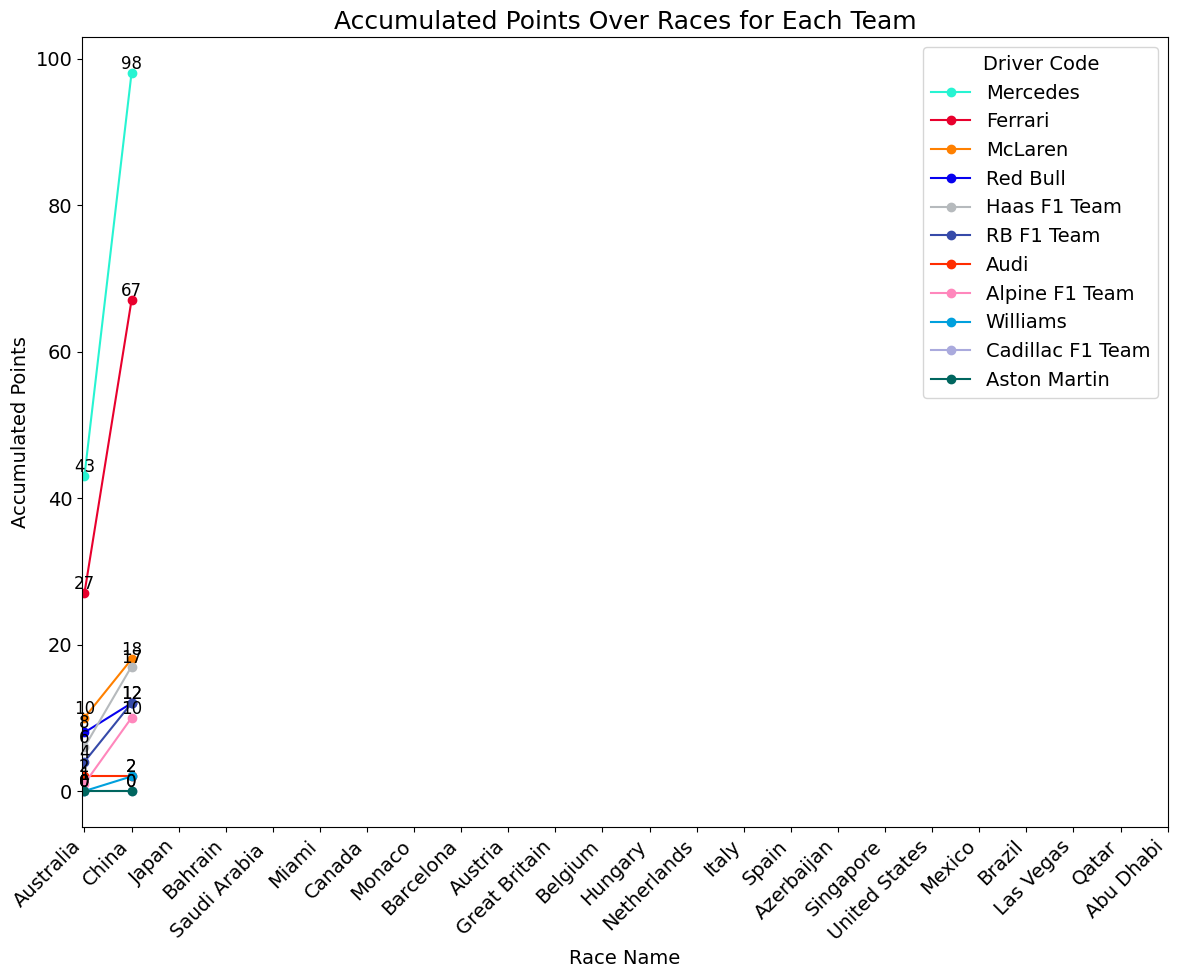

In [68]:
plt.style.use("default")
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(12, 10))

for TEAM in TEAMS:
    TEAM_DATA = RESULTS_TEAMS[RESULTS_TEAMS['CONSTRUCTOR_NAME'] == TEAM]
    TEAM_FIRST_RACE = TEAM_DATA[TEAM_DATA['ROUND'] <= ROUND_NUMBER]

    ax.plot(TEAM_FIRST_RACE['GRAND_PRIX_NAME'], TEAM_FIRST_RACE['POINTS'], 
            label=TEAM, 
            color=PALETTE_TEAMS.get(TEAM),
            marker='o')

    for x, y in zip(TEAM_FIRST_RACE['GRAND_PRIX_NAME'], TEAM_FIRST_RACE['POINTS']):
        ax.text(x, y, str(int(y)), ha='center', va='bottom', fontsize=12)

ax.set_xticks(range(len(GRAND_PRIXS["GRAND_PRIX_NAME"])))
ax.set_xticklabels(GRAND_PRIXS["GRAND_PRIX_NAME"], rotation=45, ha="right")
ax.set_xlabel("Race Name")
ax.set_ylabel("Accumulated Points")
ax.set_title("Accumulated Points Over Races for Each Team", fontsize=18)
ax.legend(title="Driver Code")

plt.tight_layout()
plt.show()